# 4D Coil Sketching: Example code to test different regularizations

Install environment first to use using the instructions in README.md. If you uncover a potential bug installing cudnn (this has happened to me before), then you can run the following in the command line to manually install (be sure to activate your correct environment first):

`python -m cupyx.tools.install_library --library cudnn --cuda 12.x`

This will install cudnn for cuda version 12.x.



### Troubleshooting: memory crashing after lots of attempts? Try the following in the first cell:

`res_scale = 0.5` --> this will set the resolution to 50% (i.e. reconstruct onto a 2-times coarser matrix. It is good for testing.)

# Setup and data loading


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.
Reconstructing onto a matrix size of: (320, 320, 128). This includes an additional 32 voxels in the x and y dimensions to help reduce wrapping artifacts.
Phases: 6; Coils: 15; Excitations: 8339; Samples: 2750
Subsetting first 50.0% nf_e
SUBSAMPLED: Phases: 6; Coils: 15; Excitations: 8339; Samples: 831
Affine transformation matrix used for saving this data: 
[[0 1 0 0]
 [0 0 1 0]
 [1 0 0 0]
 [0 0 0 1]]


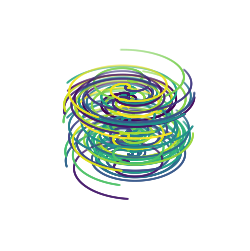

In [ ]:
import os
import sys
sys.path.append('../src')
sys.path.append('../sigpy_mod')  # Add the subdirectory to Python path
import numpy as np
import matplotlib.pyplot as plt
import sigpy      as sp
import sigpy.mri  as mr
import sigpy.plot as pl
from utils import coil_compression, crop_center, crop_2d, create_montage
import nibabel as nib
from monitor_gpu import monitor_gpu_memory  # GPU monitoring

# Setup
devnum = 0 # Device to use, set to -1 if running in CPU
toeplitz=False # Use Toeplitz to speed up A.N evaluations (i.e. the normal linear operator)
compress = True # Use SVD coil compression to compress and reorder data according to coil energy contribution
combine_csm = True # If you want to calculate 1 CSM from all combined data # Recommended to reduce memory, especially if using Toeplitz
espirit_csm = False # Use ESPIRIT instead of JSENSE (0.55T MRI data seemed to perform more reliably with ESPIRIT, but JSENSE is still a good option)
# Note: if espirit_csm is False, recon will use JSENSE. 

# Number of sketched coils (including the constant non-sketched coils)
nch = 3 
number_non_sketched_coils = nch-1 

# Additional parameters
R = 1 # Throw away some data if attempting a faster reconstruction R>=1.
lamda = 0.5 # Recommended 0.001 to 1.
scale = 1 # Intensity scale the images by this factor.
res_scale = 0.5 # Resolution scale, e.g. 0.5 means 50% of the resolution in each dimension.
coil_percentile = 100 # Keep only the top X% of coils by energy, e.g. 100 means all coils are kept, 50 means only the top 50% of coils are kept.

# List of recons: TOGGLE WHICH RECONS TO RUN
nufft=True
cg_sense = False
pdhg_sense = False
gm_sense = False
wavelet = False
tv = False
lor = False
mocolor = True
llor = False

# Device configuration
try:
    device = sp.Device(devnum)
except:
    print("Original devnum failed, using devnum 0 instead.")
    devnum=0
    device = sp.Device(devnum)
xp     = device.xp
device.use()
mvd = lambda x: sp.to_device(x, devnum)
mvc = lambda x: sp.to_device(x, sp.cpu_device)

# Load data
folder = 'data/'
additional_spatial_encoding = 32 # Optional additional spatial encoding in the x-y dimensions to help reduce wrapping artifacts (very useful if the shoulders/neck extend beyond the reconstructed FOV)
matrix_e =  (288+(additional_spatial_encoding),288+(additional_spatial_encoding),128)
print(f'Reconstructing onto a matrix size of: {matrix_e}. This includes an additional {additional_spatial_encoding} voxels in the x and y dimensions to help reduce wrapping artifacts.')
matrix_r = tuple(int(dim * res_scale) for dim in matrix_e) # Reconstructed image size, may be different from matrix_e if res_scale != 1
matrix_c = tuple(int(dim * res_scale) for dim in (288, 288, 112))  # Cropped image size
matrix_a = tuple(int(dim) for dim in (288, 288, 128))  # For density compensation
matrix_i = (288, 288)
ksp = np.load(folder + "bksp.npy")
coord = np.load(folder + "bcoord.npy")
coord[...,0] = coord[...,0]*matrix_e[0]
coord[...,1] = coord[...,1]*matrix_e[1]
coord[...,2] = coord[...,2]*matrix_e[2]
[nphase, nc0, nviews0, nread] = ksp.shape
print(f'Phases: {nphase}; Coils: {nc0}; Excitations: {nviews0}; Samples: {nread}')    

# Undersample spirals
nviews = int(nviews0/R)
ksp = ksp[...,:nviews,:]
coord = coord[:,:nviews,...] 

# Make a new folder to store the lamda value
if not os.path.exists(folder + f"/lamda_{lamda:.2e}"):
    os.makedirs(folder + f"/lamda_{lamda:.2e}/")
folder = folder + f"/lamda_{lamda:.2e}/"

# Undersample sample points along readout if res_scale < 1
nf_arr = np.sqrt(np.sum(coord[0, 0, :, :]**2, axis=1)) 
nf_e = np.sum(nf_arr < np.max(nf_arr)*res_scale)
print(f"Subsetting first {100*res_scale:.1f}% nf_e") # Note, this is not robust for VDS where the edges are more sampled than center
ksp = ksp[...,:nf_e]
coord = coord[...,:nf_e,:]
[nphase, nc, nviews, nread] = ksp.shape
print(f'SUBSAMPLED: Phases: {nphase}; Coils: {nc}; Excitations: {nviews}; Samples: {nread}') 

# Check whether a specified save data path exists
results_exist = os.path.exists(folder + "/sketching/png")

# Create a new directory because the results path does not exist
if not results_exist:
    os.makedirs(folder + "/sketching/png")
    print("A new directory inside: " + folder +
            " called 'sketching/png' has been created.")

# Save images as Nifti files
# Custom affine for coronally acquired images
aff = np.array([[0, 1, 0, 0],
                [0, 0, 1, 0],
                [1, 0, 0, 0],
                [0, 0, 0, 1]])
print("Affine transformation matrix used for saving this data: ")
print(str(aff))

# View coords
plt.figure(figsize=(3, 3), dpi=100)
ax = plt.axes(projection='3d')
N_visual = nviews//200  # Number of projections you want to show, inefficient for large n
color = iter(plt.cm.viridis(np.linspace(0, 1, N_visual)))
for i in np.linspace(0, nviews-1, N_visual):
    i = int(i)
    c = next(color)
    ax.scatter(coord[0, i, :, 0], coord[0, i, :, 1],
               coord[0, i, :, 2], color=c, s=0.5, marker='.')
ax.set_zlabel('$k_z$')
ax.set_ylabel('$k_y$')
ax.set_xlabel('$k_x$')
plt.axis("off")
# plt.savefig("coord.png", transparent=True, bbox_inches='tight', pad_inches=0)
plt.show()

def normalize(img, percentile=90):
    img_n = img/np.percentile(img.ravel(), percentile)
    return img_n

## [OPTIONAL]: apply a Hanning filter to raw k-space data to reduce high frequency noise 

For highly noisy images, this could be useful in enhancing edges. You can speed it up by moving to the GPU using `cupy` functionality.



In [2]:
from scipy.signal.windows import tukey
ksp_filter_3d = False

def apply_tukey_filter(ksp, coords, tukey_alpha=0.2):
    """
    Applies a Tukey filter to k-space data based on the spatial location in kx, ky, kz.

    Parameters:
        ksp (np.ndarray): K-space data of shape (nc, nexc, nread).
        coords (np.ndarray): Coordinates of k-space samples of shape (nexc, nread, 3).
        tukey_alpha (float): Alpha parameter for the Tukey filter (0 = rectangular, 1 = Hann).

    Returns:
        np.ndarray: Filtered k-space data of the same shape as input ksp.
    """
    # Initialize filtered k-space array
    filtered_ksp = np.copy(ksp)

    # Find the max range in each dimension for normalization
    max_kx, max_ky, max_kz = np.max(np.abs(coords[..., 0])), np.max(np.abs(coords[..., 1])), np.max(np.abs(coords[..., 2]))
    
    # Create Tukey windows in each k-space dimension
    tukey_kx = tukey(len(np.unique(coords[..., 0])), tukey_alpha)
    tukey_ky = tukey(len(np.unique(coords[..., 1])), tukey_alpha)
    tukey_kz = tukey(len(np.unique(coords[..., 2])), tukey_alpha)
    
    # Normalize coordinates to index ranges in each dimension
    for i in range(coords.shape[0]):
        for j in range(coords.shape[1]):
            # Normalize kx, ky, kz to indices in Tukey windows
            idx_kx = int(((coords[i, j, 0] / max_kx) + 1) / 2 * (len(tukey_kx) - 1))
            idx_ky = int(((coords[i, j, 1] / max_ky) + 1) / 2 * (len(tukey_ky) - 1))
            idx_kz = int(((coords[i, j, 2] / max_kz) + 1) / 2 * (len(tukey_kz) - 1))
            
            # Apply the Tukey filter to the corresponding k-space point
            filter_value = tukey_kx[idx_kx] * tukey_ky[idx_ky] * tukey_kz[idx_kz]
            filtered_ksp[:, i, j] *= filter_value

    return filtered_ksp

if ksp_filter_3d:
    for i in range(nphase):
        ksp[i, ...] = apply_tukey_filter(ksp[i,...], coord[i, ...], tukey_alpha=0.1)
        print(f'3D Tukey filter applied to phase {i}.')


## Estimate k-space preconditioner

We opted for Frank Ong's k-space preconditioner versus the more traditional Pipe-Menon DCF, as it is more robust for iterative reconstructions with large numbers of iterations. Adjust accordingly.

Calculating preconditioner...
dens.shape: (6, 1, 8339, 831)


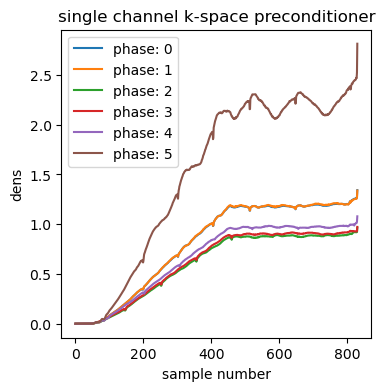

In [3]:
# Estimate k-space preconditioner
print("Calculating preconditioner...")
dens = np.zeros((nphase, 1, nviews, nread))
use_dcf = False # Use Pipe-Menon density compensation function instead of preconditioning (not as robust as preconditioning, but may offer prettier images)
t2star_weighting = False # Additional T2* weighting to the density compensation function
for resp in range(nphase):
    if use_dcf:
        dens[resp,0,...] = mvc(mr.pipe_menon_dcf(coord[resp,...], matrix_a, device=device, max_iter=30))
        
        # Multiply by a Tukey window to reduce high frequency noise
        from scipy.signal.windows import tukey
        tukey_window = tukey(2*nread, alpha=0.1)  # Alpha is the shape parameter for Tukey
        dens_weighting = tukey_window[nread:]
        dens[resp,0,...] *= dens_weighting

    else:
        # Precondition using Frank Ong's convex optimization problem 
        mps_precond = np.ones((1,) + matrix_a) # TODO: decide on the correct matrix size to use here
        mps_precond /= len(mps_precond)**0.5
        dens[resp,0,...] = mvc(mr.kspace_precond(
                            mps_precond,
                            coord=sp.to_device(coord[resp,...], device),
                            device=sp.Device(device), lamda=1e-2, oversamp=1.5))
        
    if t2star_weighting:
        # Estimate T2* decay	
        t2_star = 9  # ms # Assumed for 0.55T MRI data, adjust as needed	
        readout = 5 # ms	
        dwell_time = readout/nread	
        relaxation = np.zeros((nread,))	
        for jj in range(nread):	
            relaxation[jj] = np.exp(-(jj*dwell_time)/t2_star)**0.5
        dens[resp,0,:,:] *= relaxation
print(f"dens.shape: {dens.shape}")

# Normalize all to the same relative intensity
dens /= np.median(dens) 

# Plot
fig, (ax1) = plt.subplots(
    1, figsize=(4, 4), dpi=100)
for resp in range(nphase):
    ax1.plot(np.arange(nread), dens[resp, 0, 0,:], label=f'phase: {resp}') 
ax1.set_ylabel('dens')
if use_dcf:
    ax1.set_title("Pipe-Menon density compensation")
else:
    ax1.set_title("single channel k-space preconditioner")
ax1.set_xlabel("sample number")
plt.legend()
plt.show()

## Perform SVD coil compression

This works by first performing SVD on the raw k-space data, and then by reordering the data according to the size of each Eigenvalue. This allows you to "subset" the X number of coils with the largest contribution. However, for coil sketching, we keep all data without subsetting. We just perform the SVD part to reorder k-space data from high to low coil energy. The motivation for this comes from the coil sketching "selection" process, where higher energy coils are preferentially selected over lower energy coils. This allows faster convergence as the reconstruction favors coils with larger contribution. There are setups where this may not be favorable. For instance, if you tuned your coil selection process to be entirely random (Uniformly distributed). 

Running coil compression on all data combined into one array...
ksp.shape before coil compression: (6, 15, 8339, 831)


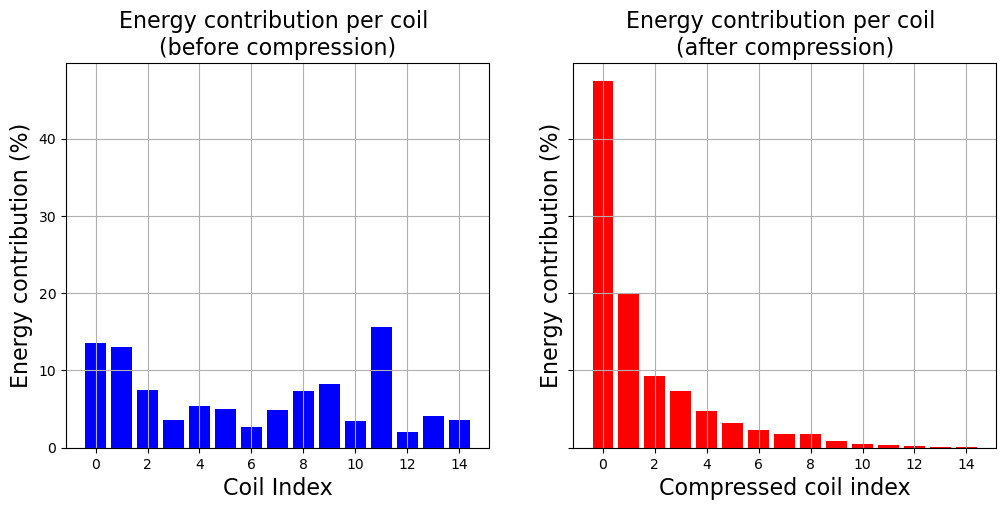

Percent energy per coil: [47.43 20.07  9.27  7.35  4.79  3.21  2.23  1.79  1.74  0.84  0.53  0.38
  0.17  0.14  0.05]
15 coils contain 100% of the total energy (for reference only).
eigenvalues[...,-4,-3,-2,-1] following coil-compression: ...[1.00296037e+09 4.52673512e+08 3.73747520e+08 1.42592505e+08]
LARGE COIL COMPRESSING TO 15 COILS


In [4]:
# Coil compression steps
if compress:
    if combine_csm: # WARNING: may not work as well if lots of excitations shared
        nc0 = ksp.shape[1]
        print("Running coil compression on all data combined into one array...")
        ksp_full = np.zeros((nc0,nphase*nviews,nread), dtype=complex)
        for coil in range(nc0): # Run through each coil individually
            # TODO: remove duplicate rows
            ksp_full[coil, ...] = ksp[:,coil,...].reshape((nphase*nviews,nread))
        ksp_full = mvd(ksp_full)
        print(f"ksp.shape before coil compression: {ksp.shape}")
        ksp_full, eigenvalues, nc = coil_compression(ksp_full, percentile=coil_percentile)
        ksp_full = mvc(ksp_full)
        for coil in range(nc0): # Run through each coil individually
            ksp[:,coil, ...] = ksp_full[coil,...].reshape((nphase, nviews,nread))
        print(f"eigenvalues[...,-4,-3,-2,-1] following coil-compression: ...{eigenvalues[-4:]}")
        ksp = mvc(ksp)
        del ksp_full
        del coil_compression
    else:       
        print("Running coil compression on each respiratory frame...")
        ksp = mvd(ksp[:,:,:nviews,...])
        print(f"ksp.shape before coil compression: {ksp.shape}")
        for resp in range(nphase):
            ksp[resp,...], eigenvalues, nc = coil_compression(ksp[resp,...], percentile=coil_percentile)
            print(f"phase {resp}: eigenvalues[...,-4,-3,-2,-1] following coil-compression: ...{eigenvalues[-4:]}")
        ksp = mvc(ksp)
        
if compress:
    if nc0 == 15:
        print(f"LARGE COIL COMPRESSING TO {nc} COILS")
        nc = nc
    elif nc0 == 21:
        nc = nc # 18
        print(f"MEDIUM COIL COMPRESSING TO {nc} COILS")
                
    if 'pdw' in folder:
        nc = nc0
        print("NOT REDUCING COILS AS PDW IMAGE AND AIMING TO MAXIMIZE SIGNAL")


# Subsample coil channels and declare variables
ksp_us = ksp[:,:nc,:nviews,...] 
coord_us = coord[:,:nviews,...] 
dens_us = dens[:,:,:nviews,...]
del(ksp)


## Estimate coil sensitivity maps

In this code block, we use J-SENSE NLINV (built in SigPy feature for non-Cartesian data) to estimate coil sensitivities for each respiratory phase individually (i.e. when `combine_csm = False`). For most cases on our end, we found that the coil sensitivity estimations were more in line with expectations when we first combined all respiratory phase data together, and then estimated the maps on the larger k-space array. This may vary site-to-site, application to application.

In [5]:
print("Calculating csm...")
mps = np.zeros([nphase] + [nc] + list(matrix_r), dtype=complex)
if combine_csm == False:
    for resp in range(nphase):
        mps[resp,...] = mvc(sp.mri.app.JsenseRecon(ksp_us[resp,:nc,...], 
                                                coord=coord_us[resp,...],
                                                weights=dens_us[resp,0,...], # TODO: decide if helpful
                                                mps_ker_width=5, # Smaller leads to lower res mps, but maybe good if smoothing over lungs
                                                ksp_calib_width=20, 
                                                lamda=1e-2,
                                                img_shape=matrix_r, 
                                                device=device, 
                                                max_iter=30, 
                                                max_inner_iter=20, 
                                                show_pbar=True).run())
        # mps[resp,...] = mps_precond

    sp.plot.ImagePlot(mps[resp], x=1, y=2, z=0,
                                title=f"[MAG] Sensitivity maps estimated with J-SENSE NLINV for respiratory phase {resp}", colormap='gray', mode='m')
    sp.plot.ImagePlot(mps[resp], x=1, y=2, z=0,
                                title=f"[PHASE] Sensitivity maps estimated with J-SENSE NLINV for respiratory phase {resp}", colormap='hsv', mode='p')


    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(mps[0,...], 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/csm_phase_0')

    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

Calculating csm...


## Attempt to calculate CSM using JSENSE (Cartesian) or ESPIRIT

In this code block, we perform more experimentation with sensitivity map estimations. This time, we use a custom function that automatically grids the non-Cartesian data onto a Cartesian grid, and then uses J-SENSE or ESPIRIT reconstruction to estimate coil maps. Depending on application, this approach could be favorable. It is worth exploring in more detail.

In [6]:
sys.path.append('../sigpy_mod')
import csm
import importlib
importlib.reload(csm)
if combine_csm is False:
    if espirit_csm:

        print("Calculating csm...")
        mps_jsense = np.zeros([nphase] + [nc] + list(matrix_r), dtype=complex)
        mps_espirit = np.zeros([nphase] + [nc] + list(matrix_r), dtype=complex)
        for resp in range(nphase):
            mps_jsense[resp,...] = csm.jsense_csm(ksp_us[resp,:nc,...], coord_us[resp,...], dens_us[resp,0,...], matrix_r, device,
                                            mps_ker_width=5,
                                            ksp_calib_width=24,
                                            lamda=1e-4,)
            mps_espirit[resp,...] = csm.espirit_csm(ksp_us[resp,:nc,...], coord_us[resp,...], dens_us[resp,0,...], matrix_r, device, 
                            crop=0,
                            thresh=0.02,
                                kernel_width=6,
                                calib_width=24,
                                max_iter=100).get()
            
        sp.plot.ImagePlot(mps_jsense[resp,...], x=1, y=2, z=0,
                                    title=f"MPS jsense respiratory phase {resp}", colormap='gray', mode='m')
        sp.plot.ImagePlot(mps_jsense[resp,...], x=1, y=2, z=0,
                                    title=f"MPS jsense respiratory phase {resp}", colormap='hsv', mode='p')
        sp.plot.ImagePlot(mps_espirit[resp,...], x=1, y=2, z=0,
                                    title=f"[MAG] MPS espirit respiratory phase {resp}", colormap='gray', mode='m')    
        sp.plot.ImagePlot(mps_espirit[resp,...], x=1, y=2, z=0,
                                    title=f"[PHASE] MPS espirit respiratory phase {resp}", colormap='hsv', mode='p')


        # FORCEFULLY OVERWRITE MPS WITH OUR NEW ONE
        # mps = mps_jsense
        mps = mps_espirit
        del mps_espirit, mps_jsense

        import cupy as cp
        cp._default_memory_pool.free_all_blocks()


        # rss = np.linalg.norm(mps[resp, :,...], axis=0) 

        # sp.plot.ImagePlot(rss, x=1, y=2, z=0,
        #                             title=f"rss", colormap='gray', mode='m')

## Estimate coil sensitivity maps from all respiratory-phase data combined into one array

Here, we estimate the coil sensitivity maps on all k-space data combined into one array. For our purposes, this worked most successfully, as it was less susceptible to undersampling artifacts caused by the relatively-under-sampled respiratory-phase k-space data. Again, it is worth examining for your own data to see which approach works best. Or, you could use your own sensitivity maps. Please share if you have a superior approach!

Side note: if this cell blows up in memory, you have many options, such as: you could reconstruct the sensitivity maps and then resize onto a larger grid; you could reduce the amount of samples (i.e. only keep the center of k-space); or you could modify the linear operators inside the sensitivity functions to better handle GPU memory. 

Calculating csm for all phases combined together (with dcf)...


JsenseRecon:   0%|          | 0/30 [00:00<?, ?it/s]

CG iter 0/20: alpha=1.0634e+00, residual=1.3707e-01
CG iter 1/20: alpha=9.0487e-01, residual=2.5282e-02
CG iter 2/20: alpha=1.0604e+00, residual=1.7712e-03
CG iter 3/20: alpha=1.0793e+00, residual=2.5110e-04
CG iter 4/20: alpha=9.4630e-01, residual=6.0438e-05
CG iter 5/20: alpha=1.0049e+00, residual=5.0973e-06
CG iter 6/20: alpha=1.0770e+00, residual=5.1922e-07
CG iter 7/20: alpha=1.1279e+00, residual=1.0318e-07
CG iter 8/20: alpha=8.5357e-01, residual=1.3898e-08
CG iter 9/20: alpha=1.0696e+00, residual=1.2849e-09
CG iter 10/20: alpha=1.1314e+00, residual=1.5326e-10
CG iter 11/20: alpha=1.0080e+00, residual=3.5004e-11
CG iter 12/20: alpha=8.9983e-01, residual=3.5124e-12
CG iter 13/20: alpha=1.1291e+00, residual=3.6435e-13
CG iter 14/20: alpha=1.1480e+00, residual=4.8863e-14
CG iter 15/20: alpha=9.0608e-01, residual=9.7156e-15
CG iter 16/20: alpha=9.5416e-01, residual=9.5399e-16
CG iter 17/20: alpha=1.1955e+00, residual=9.0486e-17
CG iter 18/20: alpha=1.0858e+00, residual=6.9319e-18
CG 

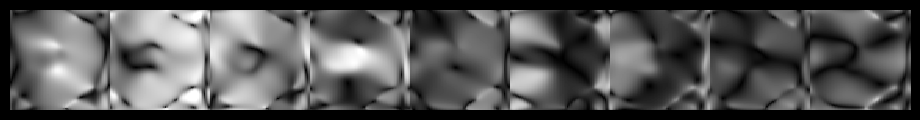

CG iter 0/20: alpha=5.9069e-01, residual=1.0259e-01
CG iter 1/20: alpha=8.4509e-01, residual=6.1553e-02
CG iter 2/20: alpha=8.7920e-01, residual=3.6340e-02
CG iter 3/20: alpha=9.5142e-01, residual=2.3665e-02
CG iter 4/20: alpha=9.6405e-01, residual=1.5843e-02
CG iter 5/20: alpha=1.0256e+00, residual=1.1598e-02
CG iter 6/20: alpha=1.0369e+00, residual=8.1807e-03
CG iter 7/20: alpha=1.0425e+00, residual=5.6425e-03
CG iter 8/20: alpha=1.1369e+00, residual=3.9514e-03
CG iter 9/20: alpha=1.2034e+00, residual=2.8761e-03
CG iter 10/20: alpha=1.1164e+00, residual=2.0737e-03
CG iter 11/20: alpha=1.2591e+00, residual=1.4591e-03
CG iter 12/20: alpha=1.0700e+00, residual=1.0026e-03
CG iter 13/20: alpha=1.3029e+00, residual=7.6398e-04
CG iter 14/20: alpha=1.1492e+00, residual=5.1193e-04
CG iter 15/20: alpha=1.3163e+00, residual=3.6543e-04
CG iter 16/20: alpha=1.2331e+00, residual=2.6180e-04
CG iter 17/20: alpha=1.1848e+00, residual=1.9183e-04
CG iter 18/20: alpha=1.1549e+00, residual=1.3296e-04
CG 

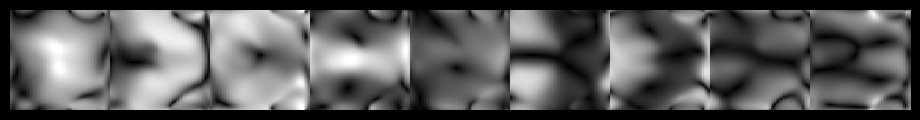

CG iter 0/20: alpha=5.8121e-01, residual=3.5517e-02
CG iter 1/20: alpha=9.7600e-01, residual=2.7467e-02
CG iter 2/20: alpha=1.0373e+00, residual=2.1784e-02
CG iter 3/20: alpha=1.0589e+00, residual=1.6320e-02
CG iter 4/20: alpha=1.1027e+00, residual=1.3921e-02
CG iter 5/20: alpha=1.1360e+00, residual=1.1736e-02
CG iter 6/20: alpha=1.1771e+00, residual=1.0644e-02
CG iter 7/20: alpha=1.1146e+00, residual=8.6406e-03
CG iter 8/20: alpha=1.2155e+00, residual=7.0919e-03
CG iter 9/20: alpha=1.1830e+00, residual=5.8379e-03
CG iter 10/20: alpha=1.1538e+00, residual=4.4532e-03
CG iter 11/20: alpha=1.5026e+00, residual=3.8973e-03
CG iter 12/20: alpha=1.2146e+00, residual=3.1140e-03
CG iter 13/20: alpha=1.2601e+00, residual=2.6322e-03
CG iter 14/20: alpha=1.2844e+00, residual=2.1237e-03
CG iter 15/20: alpha=1.2525e+00, residual=1.7016e-03
CG iter 16/20: alpha=1.5381e+00, residual=1.4575e-03
CG iter 17/20: alpha=1.3901e+00, residual=1.2321e-03
CG iter 18/20: alpha=1.0899e+00, residual=9.9565e-04
CG 

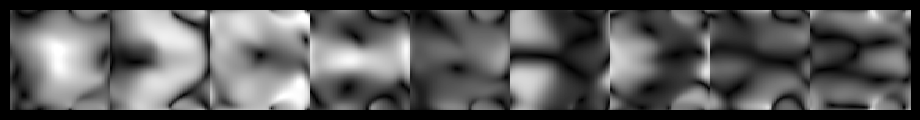

CG iter 0/20: alpha=5.1781e-01, residual=1.7196e-02
CG iter 1/20: alpha=8.7559e-01, residual=1.2037e-02
CG iter 2/20: alpha=9.6930e-01, residual=9.8085e-03
CG iter 3/20: alpha=1.0452e+00, residual=7.3019e-03
CG iter 4/20: alpha=1.0475e+00, residual=6.2070e-03
CG iter 5/20: alpha=1.2400e+00, residual=5.5835e-03
CG iter 6/20: alpha=1.1638e+00, residual=5.3238e-03
CG iter 7/20: alpha=1.2247e+00, residual=4.5668e-03
CG iter 8/20: alpha=1.2952e+00, residual=4.0082e-03
CG iter 9/20: alpha=1.1554e+00, residual=3.5992e-03
CG iter 10/20: alpha=1.2126e+00, residual=2.8807e-03
CG iter 11/20: alpha=1.5338e+00, residual=2.6247e-03
CG iter 12/20: alpha=1.2715e+00, residual=2.1803e-03
CG iter 13/20: alpha=1.2986e+00, residual=1.8729e-03
CG iter 14/20: alpha=1.2993e+00, residual=1.7435e-03
CG iter 15/20: alpha=1.2493e+00, residual=1.4675e-03
CG iter 16/20: alpha=1.4477e+00, residual=1.2974e-03
CG iter 17/20: alpha=1.5196e+00, residual=1.2213e-03
CG iter 18/20: alpha=1.1807e+00, residual=1.0520e-03
CG 

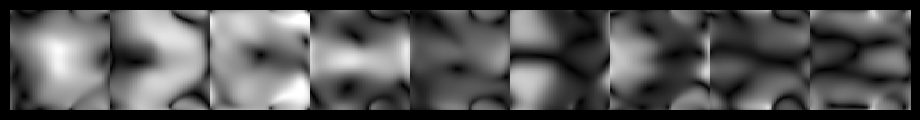

CG iter 0/20: alpha=4.8052e-01, residual=1.1611e-02
CG iter 1/20: alpha=8.2936e-01, residual=7.8702e-03
CG iter 2/20: alpha=8.7476e-01, residual=6.2297e-03
CG iter 3/20: alpha=9.8670e-01, residual=4.5993e-03
CG iter 4/20: alpha=9.7231e-01, residual=3.5314e-03
CG iter 5/20: alpha=1.2646e+00, residual=3.0628e-03
CG iter 6/20: alpha=1.1176e+00, residual=2.7394e-03
CG iter 7/20: alpha=1.2486e+00, residual=2.3065e-03
CG iter 8/20: alpha=1.3407e+00, residual=2.0175e-03
CG iter 9/20: alpha=1.1167e+00, residual=1.8214e-03
CG iter 10/20: alpha=1.1929e+00, residual=1.5441e-03
CG iter 11/20: alpha=1.4417e+00, residual=1.4808e-03
CG iter 12/20: alpha=1.2533e+00, residual=1.2335e-03
CG iter 13/20: alpha=1.3611e+00, residual=1.0727e-03
CG iter 14/20: alpha=1.2441e+00, residual=9.8787e-04
CG iter 15/20: alpha=1.2152e+00, residual=8.7522e-04
CG iter 16/20: alpha=1.3518e+00, residual=7.4790e-04
CG iter 17/20: alpha=1.4844e+00, residual=7.2535e-04
CG iter 18/20: alpha=1.2076e+00, residual=6.5724e-04
CG 

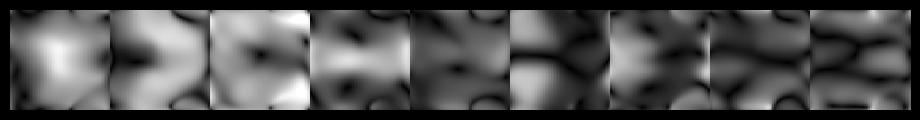

CG iter 0/20: alpha=4.5213e-01, residual=9.0534e-03
CG iter 1/20: alpha=7.9574e-01, residual=6.1176e-03
CG iter 2/20: alpha=8.3164e-01, residual=4.8204e-03
CG iter 3/20: alpha=9.6678e-01, residual=3.6685e-03
CG iter 4/20: alpha=9.5411e-01, residual=2.7376e-03
CG iter 5/20: alpha=1.2005e+00, residual=2.3767e-03
CG iter 6/20: alpha=1.0421e+00, residual=1.9488e-03
CG iter 7/20: alpha=1.2688e+00, residual=1.6072e-03
CG iter 8/20: alpha=1.2999e+00, residual=1.4055e-03
CG iter 9/20: alpha=1.1219e+00, residual=1.1910e-03
CG iter 10/20: alpha=1.2789e+00, residual=1.0506e-03
CG iter 11/20: alpha=1.2889e+00, residual=1.0068e-03
CG iter 12/20: alpha=1.2372e+00, residual=8.2339e-04
CG iter 13/20: alpha=1.3699e+00, residual=7.2994e-04
CG iter 14/20: alpha=1.2024e+00, residual=6.5124e-04
CG iter 15/20: alpha=1.2020e+00, residual=5.7701e-04
CG iter 16/20: alpha=1.3480e+00, residual=4.9197e-04
CG iter 17/20: alpha=1.4138e+00, residual=4.5597e-04
CG iter 18/20: alpha=1.2876e+00, residual=4.2262e-04
CG 

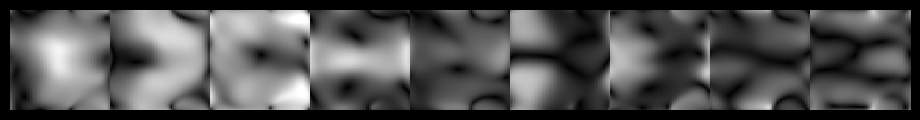

CG iter 0/20: alpha=4.3012e-01, residual=7.5577e-03
CG iter 1/20: alpha=7.5924e-01, residual=5.0361e-03
CG iter 2/20: alpha=8.0715e-01, residual=3.9801e-03
CG iter 3/20: alpha=9.4364e-01, residual=3.1319e-03
CG iter 4/20: alpha=9.2885e-01, residual=2.3500e-03
CG iter 5/20: alpha=1.1003e+00, residual=2.0093e-03
CG iter 6/20: alpha=1.0635e+00, residual=1.5666e-03
CG iter 7/20: alpha=1.2829e+00, residual=1.3103e-03
CG iter 8/20: alpha=1.2151e+00, residual=1.1409e-03
CG iter 9/20: alpha=1.1798e+00, residual=9.3607e-04
CG iter 10/20: alpha=1.3226e+00, residual=8.5282e-04
CG iter 11/20: alpha=1.2032e+00, residual=7.9770e-04
CG iter 12/20: alpha=1.2719e+00, residual=6.6582e-04
CG iter 13/20: alpha=1.2885e+00, residual=5.8823e-04
CG iter 14/20: alpha=1.2306e+00, residual=5.0617e-04
CG iter 15/20: alpha=1.2638e+00, residual=4.5754e-04
CG iter 16/20: alpha=1.2924e+00, residual=3.9105e-04
CG iter 17/20: alpha=1.4079e+00, residual=3.3610e-04
CG iter 18/20: alpha=1.4923e+00, residual=3.0814e-04
CG 

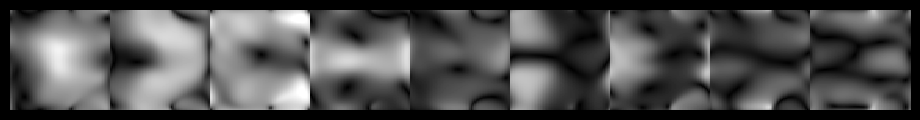

CG iter 0/20: alpha=4.1230e-01, residual=6.5781e-03
CG iter 1/20: alpha=7.2346e-01, residual=4.2709e-03
CG iter 2/20: alpha=7.8631e-01, residual=3.3830e-03
CG iter 3/20: alpha=9.1301e-01, residual=2.7311e-03
CG iter 4/20: alpha=8.9823e-01, residual=2.0674e-03
CG iter 5/20: alpha=1.0493e+00, residual=1.7035e-03
CG iter 6/20: alpha=1.1204e+00, residual=1.3250e-03
CG iter 7/20: alpha=1.2257e+00, residual=1.1273e-03
CG iter 8/20: alpha=1.1334e+00, residual=9.5257e-04
CG iter 9/20: alpha=1.2540e+00, residual=7.8558e-04
CG iter 10/20: alpha=1.2908e+00, residual=7.1351e-04
CG iter 11/20: alpha=1.2210e+00, residual=6.5373e-04
CG iter 12/20: alpha=1.3011e+00, residual=5.7145e-04
CG iter 13/20: alpha=1.2006e+00, residual=4.8609e-04
CG iter 14/20: alpha=1.3075e+00, residual=4.2065e-04
CG iter 15/20: alpha=1.2327e+00, residual=3.9050e-04
CG iter 16/20: alpha=1.2130e+00, residual=3.2671e-04
CG iter 17/20: alpha=1.4312e+00, residual=2.7976e-04
CG iter 18/20: alpha=1.3695e+00, residual=2.6215e-04
CG 

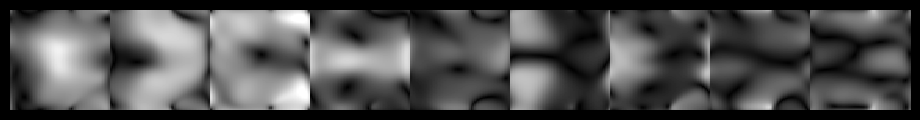

CG iter 0/20: alpha=3.9751e-01, residual=5.8861e-03
CG iter 1/20: alpha=6.9075e-01, residual=3.6917e-03
CG iter 2/20: alpha=7.6501e-01, residual=2.9214e-03
CG iter 3/20: alpha=8.7608e-01, residual=2.3944e-03
CG iter 4/20: alpha=8.7073e-01, residual=1.8186e-03
CG iter 5/20: alpha=1.0373e+00, residual=1.4580e-03
CG iter 6/20: alpha=1.1496e+00, residual=1.1552e-03
CG iter 7/20: alpha=1.1401e+00, residual=9.7962e-04
CG iter 8/20: alpha=1.1239e+00, residual=8.0245e-04
CG iter 9/20: alpha=1.3275e+00, residual=6.7477e-04
CG iter 10/20: alpha=1.2721e+00, residual=6.0115e-04
CG iter 11/20: alpha=1.2635e+00, residual=5.5434e-04
CG iter 12/20: alpha=1.2526e+00, residual=4.9865e-04
CG iter 13/20: alpha=1.1732e+00, residual=4.0536e-04
CG iter 14/20: alpha=1.3890e+00, residual=3.5868e-04
CG iter 15/20: alpha=1.1809e+00, residual=3.3688e-04
CG iter 16/20: alpha=1.1888e+00, residual=2.7493e-04
CG iter 17/20: alpha=1.5002e+00, residual=2.3345e-04
CG iter 18/20: alpha=1.4253e+00, residual=2.1072e-04
CG 

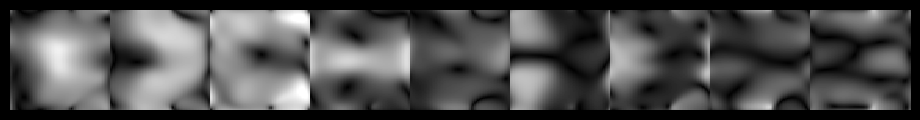

CG iter 0/20: alpha=3.8523e-01, residual=5.3653e-03
CG iter 1/20: alpha=6.6177e-01, residual=3.2419e-03
CG iter 2/20: alpha=7.4334e-01, residual=2.5516e-03
CG iter 3/20: alpha=8.3676e-01, residual=2.1064e-03
CG iter 4/20: alpha=8.4609e-01, residual=1.5961e-03
CG iter 5/20: alpha=1.0413e+00, residual=1.2638e-03
CG iter 6/20: alpha=1.1502e+00, residual=1.0227e-03
CG iter 7/20: alpha=1.0790e+00, residual=8.4788e-04
CG iter 8/20: alpha=1.1634e+00, residual=6.9059e-04
CG iter 9/20: alpha=1.3496e+00, residual=5.9278e-04
CG iter 10/20: alpha=1.2359e+00, residual=5.1239e-04
CG iter 11/20: alpha=1.2938e+00, residual=4.7753e-04
CG iter 12/20: alpha=1.2070e+00, residual=4.3356e-04
CG iter 13/20: alpha=1.1981e+00, residual=3.4683e-04
CG iter 14/20: alpha=1.3865e+00, residual=3.1471e-04
CG iter 15/20: alpha=1.1301e+00, residual=2.8634e-04
CG iter 16/20: alpha=1.2627e+00, residual=2.3517e-04
CG iter 17/20: alpha=1.5121e+00, residual=2.0227e-04
CG iter 18/20: alpha=1.3761e+00, residual=1.7651e-04
CG 

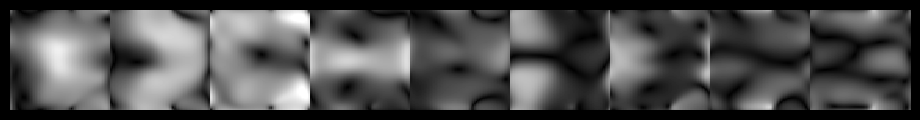

CG iter 0/20: alpha=3.7471e-01, residual=4.9556e-03
CG iter 1/20: alpha=6.3618e-01, residual=2.8875e-03
CG iter 2/20: alpha=7.2247e-01, residual=2.2513e-03
CG iter 3/20: alpha=7.9878e-01, residual=1.8633e-03
CG iter 4/20: alpha=8.2208e-01, residual=1.4011e-03
CG iter 5/20: alpha=1.0496e+00, residual=1.1080e-03
CG iter 6/20: alpha=1.1358e+00, residual=9.1024e-04
CG iter 7/20: alpha=1.0529e+00, residual=7.3674e-04
CG iter 8/20: alpha=1.2015e+00, residual=6.0903e-04
CG iter 9/20: alpha=1.3191e+00, residual=5.3062e-04
CG iter 10/20: alpha=1.2087e+00, residual=4.4562e-04
CG iter 11/20: alpha=1.3056e+00, residual=4.1730e-04
CG iter 12/20: alpha=1.1862e+00, residual=3.7890e-04
CG iter 13/20: alpha=1.2250e+00, residual=3.0920e-04
CG iter 14/20: alpha=1.2834e+00, residual=2.7987e-04
CG iter 15/20: alpha=1.1670e+00, residual=2.4126e-04
CG iter 16/20: alpha=1.4020e+00, residual=2.0728e-04
CG iter 17/20: alpha=1.4196e+00, residual=1.8523e-04
CG iter 18/20: alpha=1.1909e+00, residual=1.5734e-04
CG 

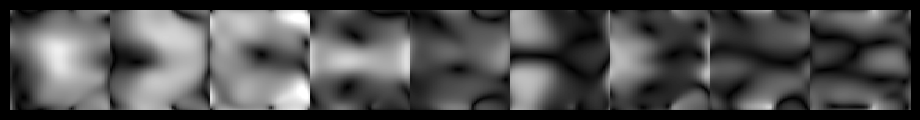

CG iter 0/20: alpha=3.6604e-01, residual=4.6291e-03
CG iter 1/20: alpha=6.1399e-01, residual=2.6079e-03
CG iter 2/20: alpha=7.0362e-01, residual=2.0101e-03
CG iter 3/20: alpha=7.6307e-01, residual=1.6622e-03
CG iter 4/20: alpha=7.9870e-01, residual=1.2375e-03
CG iter 5/20: alpha=1.0533e+00, residual=9.8008e-04
CG iter 6/20: alpha=1.1241e+00, residual=8.1268e-04
CG iter 7/20: alpha=1.0478e+00, residual=6.4954e-04
CG iter 8/20: alpha=1.2116e+00, residual=5.4747e-04
CG iter 9/20: alpha=1.2744e+00, residual=4.7801e-04
CG iter 10/20: alpha=1.2216e+00, residual=3.9544e-04
CG iter 11/20: alpha=1.3014e+00, residual=3.7193e-04
CG iter 12/20: alpha=1.1615e+00, residual=3.3633e-04
CG iter 13/20: alpha=1.2402e+00, residual=2.8044e-04
CG iter 14/20: alpha=1.2356e+00, residual=2.4567e-04
CG iter 15/20: alpha=1.2736e+00, residual=2.0971e-04
CG iter 16/20: alpha=1.4721e+00, residual=1.8467e-04
CG iter 17/20: alpha=1.4060e+00, residual=1.6472e-04
CG iter 18/20: alpha=1.1696e+00, residual=1.3935e-04
CG 

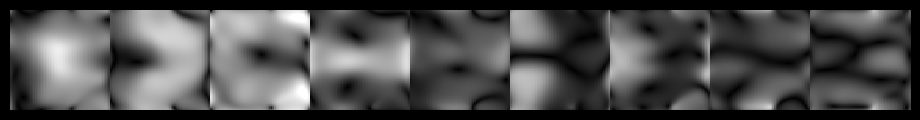

CG iter 0/20: alpha=3.5891e-01, residual=4.3630e-03
CG iter 1/20: alpha=5.9407e-01, residual=2.3847e-03
CG iter 2/20: alpha=6.8767e-01, residual=1.8150e-03
CG iter 3/20: alpha=7.3084e-01, residual=1.4984e-03
CG iter 4/20: alpha=7.7525e-01, residual=1.1023e-03
CG iter 5/20: alpha=1.0531e+00, residual=8.7433e-04
CG iter 6/20: alpha=1.1168e+00, residual=7.2974e-04
CG iter 7/20: alpha=1.0494e+00, residual=5.8144e-04
CG iter 8/20: alpha=1.2006e+00, residual=4.9787e-04
CG iter 9/20: alpha=1.2462e+00, residual=4.3211e-04
CG iter 10/20: alpha=1.2556e+00, residual=3.5680e-04
CG iter 11/20: alpha=1.2781e+00, residual=3.3672e-04
CG iter 12/20: alpha=1.1331e+00, residual=3.0146e-04
CG iter 13/20: alpha=1.2675e+00, residual=2.5412e-04
CG iter 14/20: alpha=1.2510e+00, residual=2.1737e-04
CG iter 15/20: alpha=1.3589e+00, residual=1.8674e-04
CG iter 16/20: alpha=1.5033e+00, residual=1.6518e-04
CG iter 17/20: alpha=1.4698e+00, residual=1.4327e-04
CG iter 18/20: alpha=1.2525e+00, residual=1.2338e-04
CG 

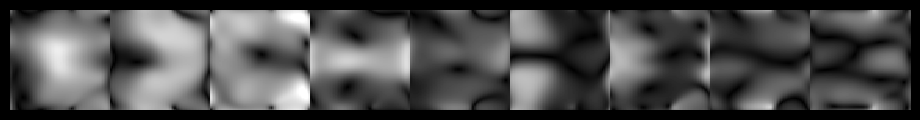

CG iter 0/20: alpha=3.5308e-01, residual=4.1438e-03
CG iter 1/20: alpha=5.7596e-01, residual=2.2048e-03
CG iter 2/20: alpha=6.7449e-01, residual=1.6559e-03
CG iter 3/20: alpha=7.0240e-01, residual=1.3651e-03
CG iter 4/20: alpha=7.5191e-01, residual=9.9143e-04
CG iter 5/20: alpha=1.0491e+00, residual=7.8613e-04
CG iter 6/20: alpha=1.1140e+00, residual=6.5994e-04
CG iter 7/20: alpha=1.0510e+00, residual=5.2747e-04
CG iter 8/20: alpha=1.1794e+00, residual=4.5550e-04
CG iter 9/20: alpha=1.2401e+00, residual=3.9311e-04
CG iter 10/20: alpha=1.2903e+00, residual=3.2705e-04
CG iter 11/20: alpha=1.2426e+00, residual=3.0829e-04
CG iter 12/20: alpha=1.1154e+00, residual=2.7214e-04
CG iter 13/20: alpha=1.3082e+00, residual=2.3109e-04
CG iter 14/20: alpha=1.2795e+00, residual=1.9605e-04
CG iter 15/20: alpha=1.3902e+00, residual=1.7071e-04
CG iter 16/20: alpha=1.4527e+00, residual=1.5408e-04
CG iter 17/20: alpha=1.3665e+00, residual=1.3678e-04
CG iter 18/20: alpha=1.1322e+00, residual=1.1391e-04
CG 

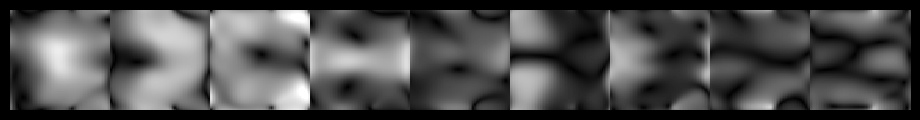

CG iter 0/20: alpha=3.4810e-01, residual=3.9610e-03
CG iter 1/20: alpha=5.5969e-01, residual=2.0585e-03
CG iter 2/20: alpha=6.6345e-01, residual=1.5249e-03
CG iter 3/20: alpha=6.7753e-01, residual=1.2558e-03
CG iter 4/20: alpha=7.2948e-01, residual=9.0027e-04
CG iter 5/20: alpha=1.0422e+00, residual=7.1198e-04
CG iter 6/20: alpha=1.1140e+00, residual=6.0110e-04
CG iter 7/20: alpha=1.0504e+00, residual=4.8344e-04
CG iter 8/20: alpha=1.1569e+00, residual=4.1829e-04
CG iter 9/20: alpha=1.2483e+00, residual=3.6045e-04
CG iter 10/20: alpha=1.3174e+00, residual=3.0410e-04
CG iter 11/20: alpha=1.2082e+00, residual=2.8483e-04
CG iter 12/20: alpha=1.1128e+00, residual=2.4825e-04
CG iter 13/20: alpha=1.3466e+00, residual=2.1248e-04
CG iter 14/20: alpha=1.2895e+00, residual=1.8106e-04
CG iter 15/20: alpha=1.3522e+00, residual=1.6092e-04
CG iter 16/20: alpha=1.3222e+00, residual=1.4734e-04
CG iter 17/20: alpha=1.2688e+00, residual=1.2944e-04
CG iter 18/20: alpha=1.1822e+00, residual=1.0248e-04
CG 

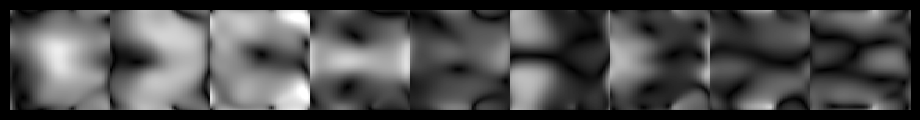

CG iter 0/20: alpha=3.4393e-01, residual=3.8064e-03
CG iter 1/20: alpha=5.4452e-01, residual=1.9382e-03
CG iter 2/20: alpha=6.5424e-01, residual=1.4150e-03
CG iter 3/20: alpha=6.5624e-01, residual=1.1655e-03
CG iter 4/20: alpha=7.0751e-01, residual=8.2472e-04
CG iter 5/20: alpha=1.0340e+00, residual=6.4923e-04
CG iter 6/20: alpha=1.1143e+00, residual=5.5140e-04
CG iter 7/20: alpha=1.0469e+00, residual=4.4631e-04
CG iter 8/20: alpha=1.1382e+00, residual=3.8538e-04
CG iter 9/20: alpha=1.2625e+00, residual=3.3302e-04
CG iter 10/20: alpha=1.3326e+00, residual=2.8485e-04
CG iter 11/20: alpha=1.1803e+00, residual=2.6426e-04
CG iter 12/20: alpha=1.1216e+00, residual=2.2808e-04
CG iter 13/20: alpha=1.3781e+00, residual=1.9718e-04
CG iter 14/20: alpha=1.2725e+00, residual=1.7036e-04
CG iter 15/20: alpha=1.2696e+00, residual=1.5270e-04
CG iter 16/20: alpha=1.2524e+00, residual=1.3686e-04
CG iter 17/20: alpha=1.3297e+00, residual=1.1941e-04
CG iter 18/20: alpha=1.2615e+00, residual=9.3972e-05
CG 

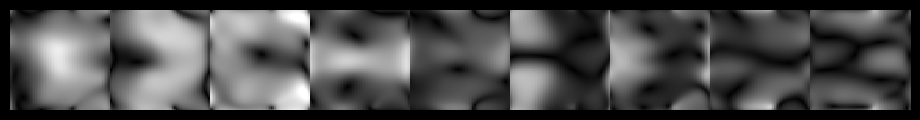

CG iter 0/20: alpha=3.4046e-01, residual=3.6747e-03
CG iter 1/20: alpha=5.3045e-01, residual=1.8379e-03
CG iter 2/20: alpha=6.4643e-01, residual=1.3221e-03
CG iter 3/20: alpha=6.3804e-01, residual=1.0900e-03
CG iter 4/20: alpha=6.8626e-01, residual=7.6168e-04
CG iter 5/20: alpha=1.0245e+00, residual=5.9572e-04
CG iter 6/20: alpha=1.1141e+00, residual=5.0873e-04
CG iter 7/20: alpha=1.0416e+00, residual=4.1408e-04
CG iter 8/20: alpha=1.1240e+00, residual=3.5620e-04
CG iter 9/20: alpha=1.2755e+00, residual=3.0938e-04
CG iter 10/20: alpha=1.3381e+00, residual=2.6774e-04
CG iter 11/20: alpha=1.1623e+00, residual=2.4568e-04
CG iter 12/20: alpha=1.1374e+00, residual=2.1075e-04
CG iter 13/20: alpha=1.3994e+00, residual=1.8430e-04
CG iter 14/20: alpha=1.2345e+00, residual=1.6155e-04
CG iter 15/20: alpha=1.1987e+00, residual=1.4294e-04
CG iter 16/20: alpha=1.2657e+00, residual=1.2607e-04
CG iter 17/20: alpha=1.4014e+00, residual=1.1096e-04
CG iter 18/20: alpha=1.2985e+00, residual=8.7124e-05
CG 

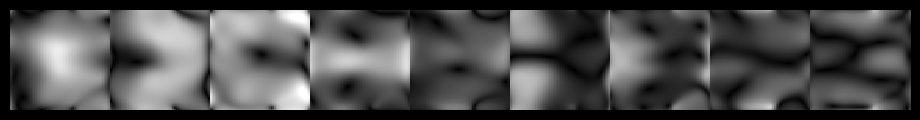

CG iter 0/20: alpha=3.3752e-01, residual=3.5611e-03
CG iter 1/20: alpha=5.1740e-01, residual=1.7534e-03
CG iter 2/20: alpha=6.3964e-01, residual=1.2426e-03
CG iter 3/20: alpha=6.2257e-01, residual=1.0260e-03
CG iter 4/20: alpha=6.6578e-01, residual=7.0843e-04
CG iter 5/20: alpha=1.0142e+00, residual=5.4967e-04
CG iter 6/20: alpha=1.1126e+00, residual=4.7145e-04
CG iter 7/20: alpha=1.0353e+00, residual=3.8534e-04
CG iter 8/20: alpha=1.1132e+00, residual=3.3009e-04
CG iter 9/20: alpha=1.2838e+00, residual=2.8832e-04
CG iter 10/20: alpha=1.3370e+00, residual=2.5182e-04
CG iter 11/20: alpha=1.1533e+00, residual=2.2858e-04
CG iter 12/20: alpha=1.1568e+00, residual=1.9536e-04
CG iter 13/20: alpha=1.4137e+00, residual=1.7280e-04
CG iter 14/20: alpha=1.1907e+00, residual=1.5289e-04
CG iter 15/20: alpha=1.1587e+00, residual=1.3256e-04
CG iter 16/20: alpha=1.3034e+00, residual=1.1664e-04
CG iter 17/20: alpha=1.4404e+00, residual=1.0366e-04
CG iter 18/20: alpha=1.3167e+00, residual=8.1182e-05
CG 

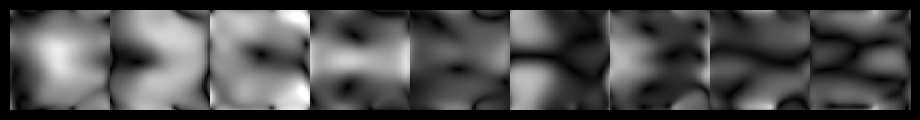

CG iter 0/20: alpha=3.3500e-01, residual=3.4620e-03
CG iter 1/20: alpha=5.0529e-01, residual=1.6815e-03
CG iter 2/20: alpha=6.3357e-01, residual=1.1738e-03
CG iter 3/20: alpha=6.0947e-01, residual=9.7111e-04
CG iter 4/20: alpha=6.4611e-01, residual=6.6288e-04
CG iter 5/20: alpha=1.0034e+00, residual=5.0965e-04
CG iter 6/20: alpha=1.1092e+00, residual=4.3830e-04
CG iter 7/20: alpha=1.0285e+00, residual=3.5919e-04
CG iter 8/20: alpha=1.1046e+00, residual=3.0642e-04
CG iter 9/20: alpha=1.2863e+00, residual=2.6898e-04
CG iter 10/20: alpha=1.3313e+00, residual=2.3651e-04
CG iter 11/20: alpha=1.1512e+00, residual=2.1258e-04
CG iter 12/20: alpha=1.1779e+00, residual=1.8123e-04
CG iter 13/20: alpha=1.4264e+00, residual=1.6183e-04
CG iter 14/20: alpha=1.1529e+00, residual=1.4388e-04
CG iter 15/20: alpha=1.1393e+00, residual=1.2263e-04
CG iter 16/20: alpha=1.3334e+00, residual=1.0830e-04
CG iter 17/20: alpha=1.4522e+00, residual=9.6983e-05
CG iter 18/20: alpha=1.3287e+00, residual=7.5776e-05
CG 

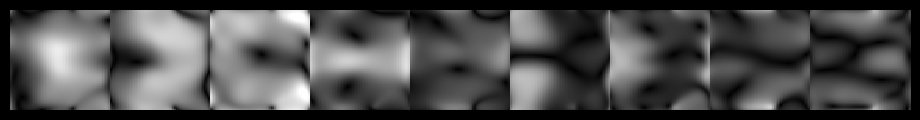

CG iter 0/20: alpha=3.3280e-01, residual=3.3745e-03
CG iter 1/20: alpha=4.9404e-01, residual=1.6195e-03
CG iter 2/20: alpha=6.2801e-01, residual=1.1137e-03
CG iter 3/20: alpha=5.9839e-01, residual=9.2337e-04
CG iter 4/20: alpha=6.2728e-01, residual=6.2345e-04
CG iter 5/20: alpha=9.9232e-01, residual=4.7457e-04
CG iter 6/20: alpha=1.1038e+00, residual=4.0843e-04
CG iter 7/20: alpha=1.0217e+00, residual=3.3507e-04
CG iter 8/20: alpha=1.0970e+00, residual=2.8472e-04
CG iter 9/20: alpha=1.2831e+00, residual=2.5088e-04
CG iter 10/20: alpha=1.3226e+00, residual=2.2159e-04
CG iter 11/20: alpha=1.1534e+00, residual=1.9749e-04
CG iter 12/20: alpha=1.1991e+00, residual=1.6800e-04
CG iter 13/20: alpha=1.4408e+00, residual=1.5100e-04
CG iter 14/20: alpha=1.1258e+00, residual=1.3468e-04
CG iter 15/20: alpha=1.1278e+00, residual=1.1339e-04
CG iter 16/20: alpha=1.3483e+00, residual=1.0068e-04
CG iter 17/20: alpha=1.4470e+00, residual=9.0626e-05
CG iter 18/20: alpha=1.3407e+00, residual=7.0685e-05
CG 

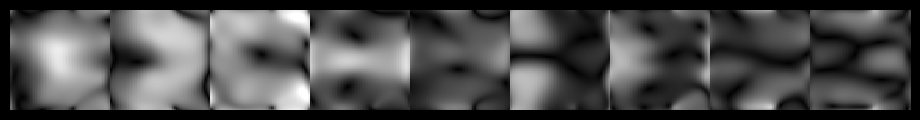

CG iter 0/20: alpha=3.3087e-01, residual=3.2963e-03
CG iter 1/20: alpha=4.8360e-01, residual=1.5655e-03
CG iter 2/20: alpha=6.2283e-01, residual=1.0607e-03
CG iter 3/20: alpha=5.8903e-01, residual=8.8147e-04
CG iter 4/20: alpha=6.0934e-01, residual=5.8900e-04
CG iter 5/20: alpha=9.8106e-01, residual=4.4364e-04
CG iter 6/20: alpha=1.0967e+00, residual=3.8130e-04
CG iter 7/20: alpha=1.0151e+00, residual=3.1273e-04
CG iter 8/20: alpha=1.0896e+00, residual=2.6472e-04
CG iter 9/20: alpha=1.2749e+00, residual=2.3381e-04
CG iter 10/20: alpha=1.3118e+00, residual=2.0704e-04
CG iter 11/20: alpha=1.1578e+00, residual=1.8326e-04
CG iter 12/20: alpha=1.2187e+00, residual=1.5556e-04
CG iter 13/20: alpha=1.4563e+00, residual=1.4041e-04
CG iter 14/20: alpha=1.1077e+00, residual=1.2554e-04
CG iter 15/20: alpha=1.1193e+00, residual=1.0481e-04
CG iter 16/20: alpha=1.3520e+00, residual=9.3533e-05
CG iter 17/20: alpha=1.4333e+00, residual=8.4458e-05
CG iter 18/20: alpha=1.3555e+00, residual=6.5816e-05
CG 

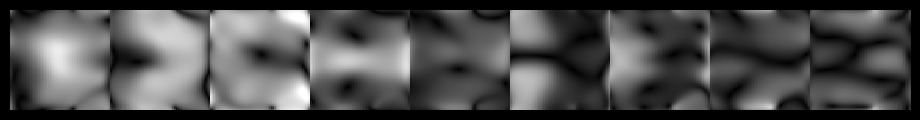

CG iter 0/20: alpha=3.2914e-01, residual=3.2258e-03
CG iter 1/20: alpha=4.7388e-01, residual=1.5181e-03
CG iter 2/20: alpha=6.1795e-01, residual=1.0138e-03
CG iter 3/20: alpha=5.8111e-01, residual=8.4442e-04
CG iter 4/20: alpha=5.9234e-01, residual=5.5871e-04
CG iter 5/20: alpha=9.6982e-01, residual=4.1630e-04
CG iter 6/20: alpha=1.0881e+00, residual=3.5664e-04
CG iter 7/20: alpha=1.0087e+00, residual=2.9208e-04
CG iter 8/20: alpha=1.0819e+00, residual=2.4633e-04
CG iter 9/20: alpha=1.2626e+00, residual=2.1776e-04
CG iter 10/20: alpha=1.2997e+00, residual=1.9304e-04
CG iter 11/20: alpha=1.1626e+00, residual=1.6995e-04
CG iter 12/20: alpha=1.2353e+00, residual=1.4404e-04
CG iter 13/20: alpha=1.4679e+00, residual=1.3056e-04
CG iter 14/20: alpha=1.0905e+00, residual=1.1669e-04
CG iter 15/20: alpha=1.1169e+00, residual=9.6771e-05
CG iter 16/20: alpha=1.3531e+00, residual=8.6784e-05
CG iter 17/20: alpha=1.4177e+00, residual=7.8482e-05
CG iter 18/20: alpha=1.3741e+00, residual=6.1169e-05
CG 

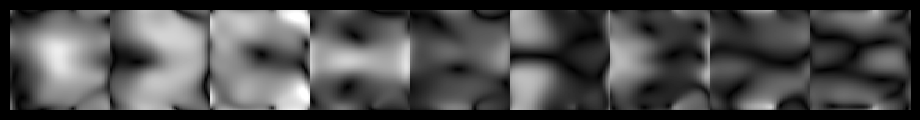

CG iter 0/20: alpha=3.2758e-01, residual=3.1615e-03
CG iter 1/20: alpha=4.6485e-01, residual=1.4760e-03
CG iter 2/20: alpha=6.1331e-01, residual=9.7199e-04
CG iter 3/20: alpha=5.7443e-01, residual=8.1146e-04
CG iter 4/20: alpha=5.7633e-01, residual=5.3198e-04
CG iter 5/20: alpha=9.5876e-01, residual=3.9214e-04
CG iter 6/20: alpha=1.0786e+00, residual=3.3431e-04
CG iter 7/20: alpha=1.0028e+00, residual=2.7316e-04
CG iter 8/20: alpha=1.0738e+00, residual=2.2956e-04
CG iter 9/20: alpha=1.2473e+00, residual=2.0284e-04
CG iter 10/20: alpha=1.2868e+00, residual=1.7980e-04
CG iter 11/20: alpha=1.1667e+00, residual=1.5768e-04
CG iter 12/20: alpha=1.2475e+00, residual=1.3359e-04
CG iter 13/20: alpha=1.4685e+00, residual=1.2201e-04
CG iter 14/20: alpha=1.0643e+00, residual=1.0826e-04
CG iter 15/20: alpha=1.1280e+00, residual=8.9211e-05
CG iter 16/20: alpha=1.3601e+00, residual=8.0423e-05
CG iter 17/20: alpha=1.4053e+00, residual=7.2775e-05
CG iter 18/20: alpha=1.3964e+00, residual=5.6796e-05
CG 

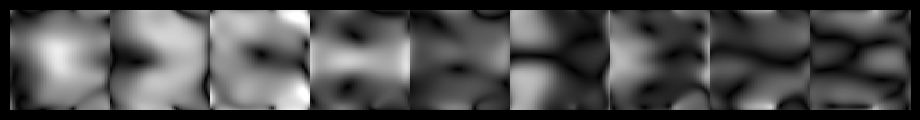

CG iter 0/20: alpha=3.2615e-01, residual=3.1024e-03
CG iter 1/20: alpha=4.5644e-01, residual=1.4383e-03
CG iter 2/20: alpha=6.0888e-01, residual=9.3455e-04
CG iter 3/20: alpha=5.6880e-01, residual=7.8202e-04
CG iter 4/20: alpha=5.6133e-01, residual=5.0835e-04
CG iter 5/20: alpha=9.4802e-01, residual=3.7084e-04
CG iter 6/20: alpha=1.0688e+00, residual=3.1421e-04
CG iter 7/20: alpha=9.9757e-01, residual=2.5601e-04
CG iter 8/20: alpha=1.0653e+00, residual=2.1443e-04
CG iter 9/20: alpha=1.2300e+00, residual=1.8916e-04
CG iter 10/20: alpha=1.2734e+00, residual=1.6751e-04
CG iter 11/20: alpha=1.1695e+00, residual=1.4652e-04
CG iter 12/20: alpha=1.2546e+00, residual=1.2430e-04
CG iter 13/20: alpha=1.4536e+00, residual=1.1494e-04
CG iter 14/20: alpha=1.0288e+00, residual=1.0022e-04
CG iter 15/20: alpha=1.1581e+00, residual=8.2226e-05
CG iter 16/20: alpha=1.3739e+00, residual=7.4521e-05
CG iter 17/20: alpha=1.3973e+00, residual=6.7442e-05
CG iter 18/20: alpha=1.4214e+00, residual=5.2757e-05
CG 

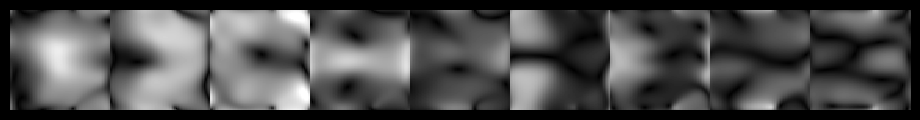

CG iter 0/20: alpha=3.2484e-01, residual=3.0477e-03
CG iter 1/20: alpha=4.4861e-01, residual=1.4043e-03
CG iter 2/20: alpha=6.0466e-01, residual=9.0091e-04
CG iter 3/20: alpha=5.6407e-01, residual=7.5562e-04
CG iter 4/20: alpha=5.4734e-01, residual=4.8743e-04
CG iter 5/20: alpha=9.3771e-01, residual=3.5211e-04
CG iter 6/20: alpha=1.0589e+00, residual=2.9624e-04
CG iter 7/20: alpha=9.9316e-01, residual=2.4061e-04
CG iter 8/20: alpha=1.0566e+00, residual=2.0092e-04
CG iter 9/20: alpha=1.2114e+00, residual=1.7682e-04
CG iter 10/20: alpha=1.2597e+00, residual=1.5632e-04
CG iter 11/20: alpha=1.1705e+00, residual=1.3652e-04
CG iter 12/20: alpha=1.2567e+00, residual=1.1617e-04
CG iter 13/20: alpha=1.4244e+00, residual=1.0900e-04
CG iter 14/20: alpha=9.9562e-01, residual=9.2598e-05
CG iter 15/20: alpha=1.2040e+00, residual=7.5972e-05
CG iter 16/20: alpha=1.3879e+00, residual=6.9166e-05
CG iter 17/20: alpha=1.3913e+00, residual=6.2570e-05
CG iter 18/20: alpha=1.4472e+00, residual=4.9096e-05
CG 

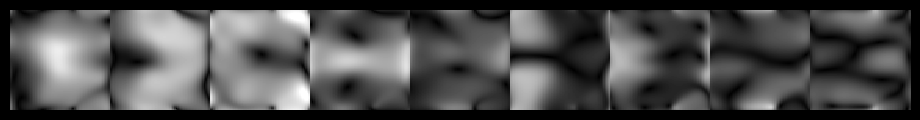

CG iter 0/20: alpha=3.2362e-01, residual=2.9966e-03
CG iter 1/20: alpha=4.4131e-01, residual=1.3734e-03
CG iter 2/20: alpha=6.0063e-01, residual=8.7055e-04
CG iter 3/20: alpha=5.6008e-01, residual=7.3186e-04
CG iter 4/20: alpha=5.3435e-01, residual=4.6888e-04
CG iter 5/20: alpha=9.2789e-01, residual=3.3565e-04
CG iter 6/20: alpha=1.0495e+00, residual=2.8026e-04
CG iter 7/20: alpha=9.8969e-01, residual=2.2691e-04
CG iter 8/20: alpha=1.0480e+00, residual=1.8897e-04
CG iter 9/20: alpha=1.1923e+00, residual=1.6581e-04
CG iter 10/20: alpha=1.2461e+00, residual=1.4627e-04
CG iter 11/20: alpha=1.1698e+00, residual=1.2765e-04
CG iter 12/20: alpha=1.2545e+00, residual=1.0909e-04
CG iter 13/20: alpha=1.3869e+00, residual=1.0369e-04
CG iter 14/20: alpha=9.7544e-01, residual=8.5608e-05
CG iter 15/20: alpha=1.2551e+00, residual=7.0516e-05
CG iter 16/20: alpha=1.3970e+00, residual=6.4394e-05
CG iter 17/20: alpha=1.3857e+00, residual=5.8201e-05
CG iter 18/20: alpha=1.4722e+00, residual=4.5828e-05
CG 

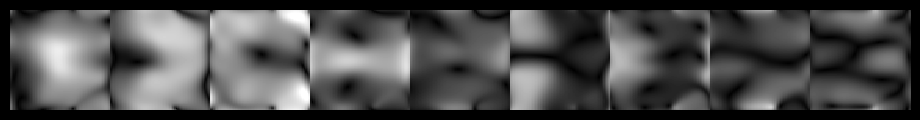

CG iter 0/20: alpha=3.2248e-01, residual=2.9487e-03
CG iter 1/20: alpha=4.3450e-01, residual=1.3452e-03
CG iter 2/20: alpha=5.9677e-01, residual=8.4305e-04
CG iter 3/20: alpha=5.5673e-01, residual=7.1038e-04
CG iter 4/20: alpha=5.2231e-01, residual=4.5238e-04
CG iter 5/20: alpha=9.1858e-01, residual=3.2120e-04
CG iter 6/20: alpha=1.0407e+00, residual=2.6609e-04
CG iter 7/20: alpha=9.8721e-01, residual=2.1477e-04
CG iter 8/20: alpha=1.0397e+00, residual=1.7848e-04
CG iter 9/20: alpha=1.1734e+00, residual=1.5608e-04
CG iter 10/20: alpha=1.2326e+00, residual=1.3736e-04
CG iter 11/20: alpha=1.1674e+00, residual=1.1984e-04
CG iter 12/20: alpha=1.2490e+00, residual=1.0292e-04
CG iter 13/20: alpha=1.3476e+00, residual=9.8666e-05
CG iter 14/20: alpha=9.7028e-01, residual=7.9435e-05
CG iter 15/20: alpha=1.3017e+00, residual=6.5807e-05
CG iter 16/20: alpha=1.4009e+00, residual=6.0182e-05
CG iter 17/20: alpha=1.3803e+00, residual=5.4331e-05
CG iter 18/20: alpha=1.4956e+00, residual=4.2944e-05
CG 

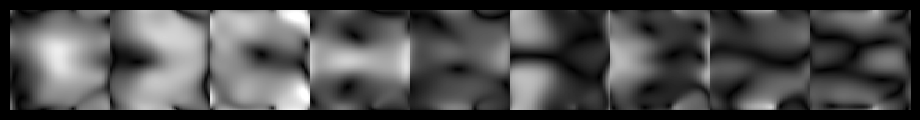

CG iter 0/20: alpha=3.2140e-01, residual=2.9035e-03
CG iter 1/20: alpha=4.2814e-01, residual=1.3192e-03
CG iter 2/20: alpha=5.9308e-01, residual=8.1803e-04
CG iter 3/20: alpha=5.5391e-01, residual=6.9088e-04
CG iter 4/20: alpha=5.1116e-01, residual=4.3766e-04
CG iter 5/20: alpha=9.0978e-01, residual=3.0847e-04
CG iter 6/20: alpha=1.0326e+00, residual=2.5353e-04
CG iter 7/20: alpha=9.8573e-01, residual=2.0405e-04
CG iter 8/20: alpha=1.0320e+00, residual=1.6928e-04
CG iter 9/20: alpha=1.1550e+00, residual=1.4755e-04
CG iter 10/20: alpha=1.2192e+00, residual=1.2951e-04
CG iter 11/20: alpha=1.1635e+00, residual=1.1299e-04
CG iter 12/20: alpha=1.2412e+00, residual=9.7531e-05
CG iter 13/20: alpha=1.3114e+00, residual=9.3856e-05
CG iter 14/20: alpha=9.7677e-01, residual=7.4110e-05
CG iter 15/20: alpha=1.3396e+00, residual=6.1753e-05
CG iter 16/20: alpha=1.4009e+00, residual=5.6483e-05
CG iter 17/20: alpha=1.3752e+00, residual=5.0928e-05
CG iter 18/20: alpha=1.5168e+00, residual=4.0417e-05
CG 

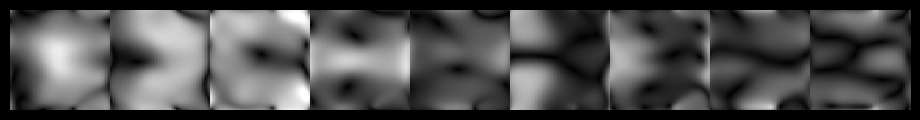

CG iter 0/20: alpha=3.2038e-01, residual=2.8607e-03
CG iter 1/20: alpha=4.2219e-01, residual=1.2950e-03
CG iter 2/20: alpha=5.8954e-01, residual=7.9517e-04
CG iter 3/20: alpha=5.5152e-01, residual=6.7309e-04
CG iter 4/20: alpha=5.0085e-01, residual=4.2447e-04
CG iter 5/20: alpha=9.0144e-01, residual=2.9724e-04
CG iter 6/20: alpha=1.0253e+00, residual=2.4240e-04
CG iter 7/20: alpha=9.8522e-01, residual=1.9456e-04
CG iter 8/20: alpha=1.0251e+00, residual=1.6123e-04
CG iter 9/20: alpha=1.1374e+00, residual=1.4008e-04
CG iter 10/20: alpha=1.2061e+00, residual=1.2264e-04
CG iter 11/20: alpha=1.1583e+00, residual=1.0700e-04
CG iter 12/20: alpha=1.2320e+00, residual=9.2791e-05
CG iter 13/20: alpha=1.2807e+00, residual=8.9302e-05
CG iter 14/20: alpha=9.9052e-01, residual=6.9557e-05
CG iter 15/20: alpha=1.3682e+00, residual=5.8256e-05
CG iter 16/20: alpha=1.3986e+00, residual=5.3239e-05
CG iter 17/20: alpha=1.3706e+00, residual=4.7947e-05
CG iter 18/20: alpha=1.5357e+00, residual=3.8210e-05
CG 

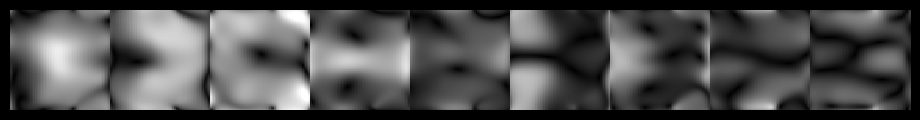

CG iter 0/20: alpha=3.1941e-01, residual=2.8200e-03
CG iter 1/20: alpha=4.1661e-01, residual=1.2725e-03
CG iter 2/20: alpha=5.8616e-01, residual=7.7419e-04
CG iter 3/20: alpha=5.4949e-01, residual=6.5677e-04
CG iter 4/20: alpha=4.9130e-01, residual=4.1259e-04
CG iter 5/20: alpha=8.9352e-01, residual=2.8729e-04
CG iter 6/20: alpha=1.0187e+00, residual=2.3252e-04
CG iter 7/20: alpha=9.8562e-01, residual=1.8616e-04
CG iter 8/20: alpha=1.0192e+00, residual=1.5417e-04
CG iter 9/20: alpha=1.1209e+00, residual=1.3354e-04
CG iter 10/20: alpha=1.1931e+00, residual=1.1662e-04
CG iter 11/20: alpha=1.1520e+00, residual=1.0177e-04
CG iter 12/20: alpha=1.2222e+00, residual=8.8601e-05
CG iter 13/20: alpha=1.2560e+00, residual=8.5066e-05
CG iter 14/20: alpha=1.0080e+00, residual=6.5664e-05
CG iter 15/20: alpha=1.3889e+00, residual=5.5230e-05
CG iter 16/20: alpha=1.3950e+00, residual=5.0391e-05
CG iter 17/20: alpha=1.3666e+00, residual=4.5335e-05
CG iter 18/20: alpha=1.5521e+00, residual=3.6284e-05
CG 

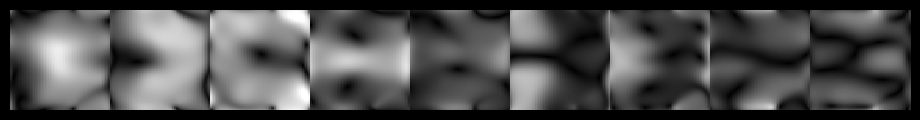

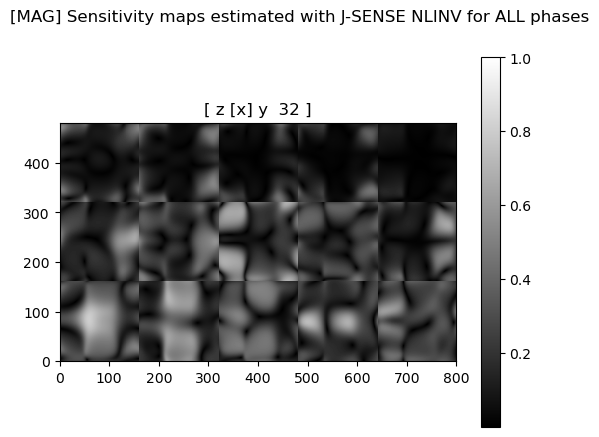

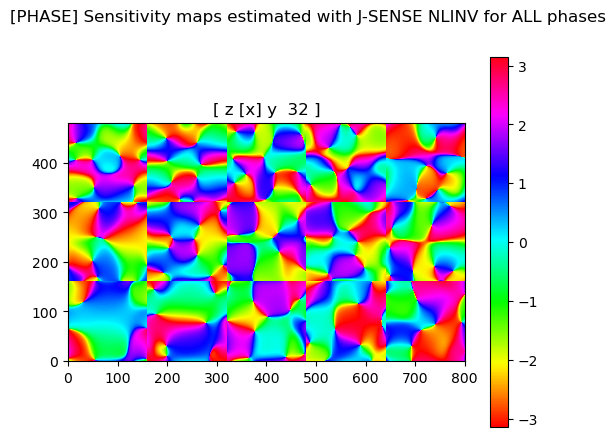

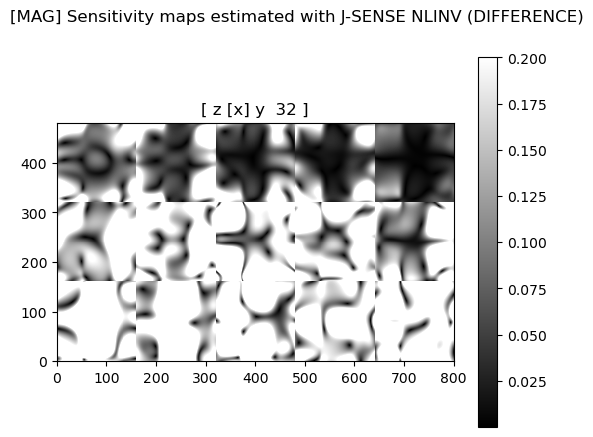

Overwriting each respiratory phase's sensitivity map with the full map.
Overwriting each respiratory phase's sensitivity map with the full map.
Overwriting each respiratory phase's sensitivity map with the full map.
Overwriting each respiratory phase's sensitivity map with the full map.
Overwriting each respiratory phase's sensitivity map with the full map.
Overwriting each respiratory phase's sensitivity map with the full map.


In [7]:
if combine_csm:
    importlib.reload(csm)
    print("Calculating csm for all phases combined together (with dcf)...")
    ksp_full = np.zeros((nc,nphase*nviews,nread), dtype=complex)
    for coil in range(nc): # Run through each phase individually
        ksp_full[coil, ...] = ksp_us[:,coil,...].reshape((nphase*nviews,nread))
    coord_full = coord_us.reshape((nphase*nviews,nread, 3))
    
    if espirit_csm:
        dens_full = mvc(mr.pipe_menon_dcf(coord_full, matrix_a, device=device, max_iter=30, width=3.5, beta=8))
        tukey_window = tukey(2*nread, alpha=0.1)  # Alpha is the shape parameter for Tukey
        dens_weighting = tukey_window[nread:]
        dens_full *= dens_weighting
        mps_full = csm.espirit_csm(ksp_full, coord_full, dens_full, matrix_r, device, 
                        crop=0,
                        thresh=0.02,
                            kernel_width=6,
                            calib_width=24-4,
                            max_iter=100,
                            downscale_factor=2).get()
        sp.plot.ImagePlot(mps_full, x=1, y=2, z=0,
                                title=f"[MAG] Sensitivity maps estimated with ESPIRIT for ALL phases", colormap='gray', mode='m',vmax=1)
        sp.plot.ImagePlot(mps_full, x=1, y=2, z=0,
                                    title=f"[PHASE] Sensitivity maps estimated with ESPIRIT for ALL phases", colormap='hsv', mode='p')
        sp.plot.ImagePlot(mps_full-mps[resp], x=1, y=2, z=0,
                                    title=f"[MAG] Sensitivity maps estimated with ESPIRIT (DIFFERENCE)", colormap='gray', mode='m', vmax=0.2)
        
    else:
        mps_precond = np.ones((1,) + matrix_a) # TODO: decide on the correct matrix size to use here
        mps_precond /= len(mps_precond)**0.5
        dens_full = mvc(mr.kspace_precond(
                                    mps_precond,
                                    coord=sp.to_device(coord_full[...], device),
                                    device=sp.Device(device), lamda=1e-2, oversamp=1.5))[0,...]
        mps_full = mvc(sp.mri.app.JsenseRecon(ksp_full, 
                                            coord=coord_full, 
                                            weights=dens_full, 
                                            mps_ker_width=6, 
                                            ksp_calib_width=20, 
                                            lamda=1e-2,
                                            img_shape=matrix_r, 
                                            device=device, 
                                            max_iter=30,
                                            max_inner_iter=20, 
                                            show_pbar=True).run())
        sp.plot.ImagePlot(mps_full, x=1, y=2, z=0,
                                title=f"[MAG] Sensitivity maps estimated with J-SENSE NLINV for ALL phases", colormap='gray', mode='m',vmax=1)
        sp.plot.ImagePlot(mps_full, x=1, y=2, z=0,
                                    title=f"[PHASE] Sensitivity maps estimated with J-SENSE NLINV for ALL phases", colormap='hsv', mode='p')
        sp.plot.ImagePlot(mps_full-mps[resp], x=1, y=2, z=0,
                                    title=f"[MAG] Sensitivity maps estimated with J-SENSE NLINV (DIFFERENCE)", colormap='gray', mode='m', vmax=0.2)
    del(ksp_full, coord_full, dens_full)



    for resp in range(nphase):
        mps[resp,...] = mps_full
        print("Overwriting each respiratory phase's sensitivity map with the full map.")
        
    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(mps[0,...], 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/csm_phase_combined')
        
import cupy as cp
cp._default_memory_pool.free_all_blocks()

## Let's do some linear algebra 

We can perform a simple "gridded" reconstruction of the raw k-space data. This is a good way to examine how under-sampled your data is, visually.

ksp_us.shape: (6, 15, 8339, 831)
coord_us.shape: (6, 8339, 831, 3)
dens_us.shape: (6, 1, 8339, 831)
mps.shape: (6, 15, 160, 160, 64)
()
done
done
done
done
shape of reconstructed image using $A^H y$ is: (15, 160, 160, 64)


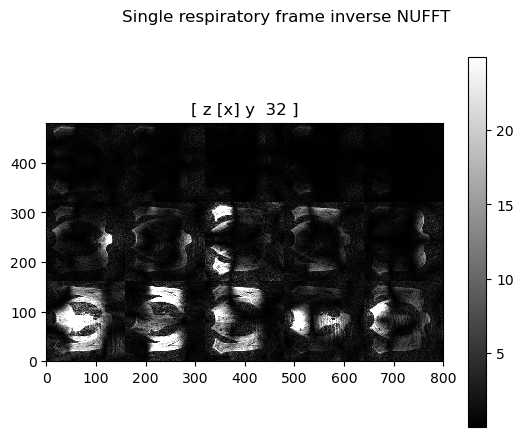

In [8]:
print(f'ksp_us.shape: {ksp_us.shape}')
print(f'coord_us.shape: {coord_us.shape}')
print(f'dens_us.shape: {dens_us.shape}')
print(f'mps.shape: {mps.shape}')
print(ksp_us[0,...].shape[:-3])

# 4D NUFFT
F = sp.linop.NUFFT(ishape=(nc,) + matrix_r,
                coord=coord_us[0,...])
print("done")
S = sp.linop.Multiply(ishape = (nc,) + matrix_r, # Keep the channel as the ishape to ensure the output image is multiple channels
                    mult=mps[0,...])
print("done")
D = sp.linop.Multiply(F.oshape, dens_us[0,...])
print("done")
A_us = D * F * S
print("done")

y = ksp_us[0,...]
y = sp.to_device(y, 1)
img_us = mvc(A_us.H(y))
y = sp.to_device(y, sp.cpu_device)
del y
scale = np.percentile(np.abs(img_us.flatten()), 95)
vmax = np.percentile(np.abs(img_us.flatten()), 99)
print(r'shape of reconstructed image using $A^H y$' + f' is: {img_us.shape}')
pl.ImagePlot(img_us, x=1, y=2, z=0,vmax=vmax, title="Single respiratory frame inverse NUFFT", colormap="gray")
del(F,S,D,A_us)     

import cupy as cp
cp._default_memory_pool.free_all_blocks()

## Let's do a bunch of GPU cleanup 

(I'm not sure which of these lines is optimal, I just know that running all of them generally clears the GPU). Someone smarter at `cupy`, please help!

In [9]:
import gc
gc.collect()

import torch
import importlib

# Get memory usage in MB
print(f"Allocated memory: {torch.cuda.memory_allocated() / 1024 ** 2} MB")
print(f"Cached memory: {torch.cuda.memory_reserved() / 1024 ** 2} MB")

import cupy as cp

# Get memory usage statistics
mempool = cp.get_default_memory_pool()
pinned_mempool = cp.get_default_pinned_memory_pool()

print(f"Used memory: {mempool.used_bytes() / 1024 ** 2} MB")
print(f"Total memory: {mempool.total_bytes() / 1024 ** 2} MB")

# To free unused memory
mempool.free_all_blocks()

# Optionally clear any pinned memory (CPU-GPU pinned transfers)
pinned_mempool.free_all_blocks()

# Clear variables stored on GPU 
cp._default_memory_pool.free_all_blocks()

# Avoiding Device Synchronization for Faster Execution
# By default, many CuPy operations perform implicit device synchronization (waiting for all 
# previous operations to complete before continuing). You can explicitly manage synchronization 
# to improve performance by deferring synchronization calls:
cp.cuda.stream.get_current_stream().synchronize()  # Manually synchronize


print(f"Used memory: {mempool.used_bytes() / 1024 ** 2} MB")
print(f"Total memory: {mempool.total_bytes() / 1024 ** 2} MB")


Allocated memory: 0.0 MB
Cached memory: 0.0 MB
Used memory: 0.0 MB
Total memory: 2398.478515625 MB
Used memory: 0.0 MB
Total memory: 0.0 MB


In [ ]:
import importlib

# Reload cupy to see if that is where the memory dump is located
importlib.reload(cp)
importlib.reload(sp)
importlib.reload(mr)
import time
time.sleep(10) # Wait a second to give it time to clear memory if not done already 

print(f"Used memory: {mempool.used_bytes() / 1024 ** 2} MB")
print(f"Total memory: {mempool.total_bytes() / 1024 ** 2} MB")



## Let's try a sketched recon using our 4D $A$ operator

In [ ]:
import sketching_4d_app as sk4d
import importlib
importlib.reload(sk4d)
importlib.reload(sp)

# Coil sketching reconstruction
max_init_iter = 4 # Initialize the recon with a few iterations using only the nch highest energy coils (similar to a coil compressed reconstruction).
max_inner_iter = 5 # Number of inner iterations per coil subset, for the sketched data consistency term. Can be reduced for very good preconditioning, and increased for poor preconditioning.
max_outer_iter = 10 # Overall number of outer iterations. If you have more sketched coils, you may be able to decrease this number. This generally worked well for nch=3-5. The higher you make it, the more random coil subsets will be included in the iterative reconstruction. In theory, a very high number will support near identical image reconstruction to a fully sampled conventional reconstruction.
np.random.seed(1)

# Clear variables stored on GPU 
import cupy as cp
cp._default_memory_pool.free_all_blocks()


/home/plummerjw/miniforge3/envs/sketching-env-cuda13/lib/python3.14/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


## Combine sensitivity maps into one (if chosen)

If using only a single coil sensitivity map for all respiratory phases (recommended for our test data), then collapse `mps` into a 4D array.


In [ ]:
if combine_csm and len(mps.shape) == 5:
    mps = mvc(mps)[0,...]
else:
    mps = mvc(mps)

## Choose whether to save objective values

Set to true if you would like to estimate the value of the overall objective function at each iteration (note, this does not use coil sketching to evaluate). This is useful if plotting convergence curves. 

WARNING: This is slow and memory intensive!!

In [ ]:
save_objective_values=False

## CG-SENSE coil sketched reconstruction

A custom implementation of CG-SENSE. While fast, this likely offers little benefit compared to a gridded reconstruction, as it is not using the temporal dimension to regularize.


In [ ]:
if cg_sense:
    # Move variables to cpu to free up space
    ksp_us = mvc(ksp_us)
    coord_us = mvc(coord_us)
    dens_us = mvc(dens_us)

        
    import sketching_4d_app as sk4d
    import sketching_app
    importlib.reload(sketching_app)
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    sys.path.append('../sigpy_mod')
    import custom_linop
    import importlib
    importlib.reload(custom_linop)
    import maxeig as me
    importlib.reload(me)
    
    # Start monitoring
    print("MONITORING GPU USAGE...")
    tic, toc, memory_usage_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    tic()
    
    if save_objective_values:
        ksp_us = mvd(ksp_us)
        dens_us = mvd(dens_us)
    sketched_cg_solver = sk4d.SketchedSenseRecon(ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda*1e3, # TODO: get MaxEig normalization to work robustly for CG-SENSE, enabling a more robust choice of lamda. For now, this works.
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='ConjugateGradient',
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum), # Must be same device as ksp and dcf 
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30, # Not used for conjugate gradient 
                                    save_objective_values=save_objective_values, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    )
    
    img_sk_cg_sense = mvc(scale*sketched_cg_solver.run())
    if save_objective_values:
        sketched_cg_sense_objective = np.array(sketched_cg_solver.objective_values)
    del sketched_cg_solver
    
    sketched_memory_cg = np.array(memory_usage_sketched)*1e-3
    toc()
    # Plot results
    plt.figure(figsize=(3,4))
    plt.plot(memory_usage_sketched)
    plt.xlabel('time')
    plt.ylabel('memory usage (MB)')
    plt.grid(True)
    plt.show()
    shutdown()
    print("GPU MONITORING COMPLETE.")
        
    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_cg_sense, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_cg_sense')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_cg_sense.ravel()), 95)
    pl.ImagePlot(img_sk_cg_sense[0,...], 
                x=1, y=3,
                title="Under-sampled Sketching Reconstruction (CG SENSE)", 
                colormap="gray", 
                vmax=vmax,
                )
    
    pl.ImagePlot(img_sk_cg_sense[0,...], 
                x=1, y=3, mode='p',
                title="PHASE Under-sampled Sketching Reconstruction (CG SENSE)", 
                colormap="jet", 
                )
    
    # Get memory usage statistics
    mempool = cp.get_default_memory_pool()
    pinned_mempool = cp.get_default_pinned_memory_pool()
    mempool.free_all_blocks()
    pinned_mempool.free_all_blocks()
    cp._default_memory_pool.free_all_blocks()
    cp.cuda.stream.get_current_stream().synchronize() 
    
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_cg_sense, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_cg_sense.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    

    
    # Move variables to cpu to free up space
    ksp_us = mvc(ksp_us)
    coord_us = mvc(coord_us)
    dens_us = mvc(dens_us)
    


## $L_1$ wavelet transform regularized reconstruction using Gradient Method

Perform a spatial L1-wavelet reconstruction, using Gradient Method as the solver. Note, this is also solvable with PDHG or FISTA.

Additionally, an extra reconstruction is shown for the "conventional" reconstruction (i.e. no coil sketching). This is akin to only running the initial iterations of the overall coil sketching algorithm, but using k-space data from all coils (instead of a subset of coils, as would be done for coil compression).

In [ ]:
if wavelet:
    # Move variables to cpu to free up space
    ksp_us = mvc(ksp_us)
    coord_us = mvc(coord_us)
    dens_us = mvc(dens_us)
        
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    sys.path.append('../sigpy_mod')
    import custom_linop
    import importlib
    importlib.reload(custom_linop)
    img_sk_wavelet = mvc(scale*sk4d.SketchedL1WaveletRecon4D(ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='GradientMethod',
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum), # Must be same device as ksp and dcf 
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    coil_batch_size=nch).run())
    # img_sk = np.rot90(mvc(img_sk), k=-1)

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_wavelet, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_wavelet')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_wavelet.ravel()), 95)
    pl.ImagePlot(img_sk_wavelet[3,...], 
                x=1, y=3,
                title="Under-sampled Sketching Reconstruction (Wavelet)", 
                colormap="gray", 
                vmax=vmax,
                )
    
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_wavelet, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_wavelet.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    
    img_wavelet = mvc(scale*sk4d.SketchedL1WaveletRecon4D(ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nc,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='GradientMethod',
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum), # Must be same device as ksp and dcf 
                                    number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter + (max_outer_iter*(max_inner_iter-1)),
                                    max_outer_iter=0,
                                    max_inner_iter=0,
                                    max_power_iter=30,
                                    coil_batch_size=nc).run())
    # img_sk = np.rot90(mvc(img_sk), k=-1)

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_wavelet, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_wavelet')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_wavelet.ravel()), 95)
    pl.ImagePlot(img_wavelet[3,...], 
                x=1, y=3,
                title="Under-sampled Reconstruction (Wavelet)", 
                colormap="gray", 
                vmax=vmax,
                )


## Total variation reconstruction (using PDHG)
Supposedly, this is faster than the gradient method used in the L1 wavelet recon.

Supposedly, it is also more robust to non-smooth regularizations such as the nuclear norm.

Conveniently, I was able leverage $G$ for the motion fields, and $proxg()$ for the nuclear norm proximal operator used in MoCo-LR (later).

In [ ]:
if tv:
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)

    # Change device to free up memory
    img_sk_tv = mvc(scale*sk4d.SketchedTotalVariationRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='PrimalDualHybridGradient', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    # TODO: Add max_cg_iter to control the conj grad iteration count. Default 10
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_tv, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_tv')
    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_tv.ravel()), 95)
    pl.ImagePlot(img_sk_tv[3,...], 
                x=1, y=3,
                title="Under-sampled Sketching Reconstruction (TV)", 
                colormap="gray", 
                vmax=vmax
                )
    
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_tv, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_tv.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    
    img_tv = mvc(scale*sk4d.SketchedTotalVariationRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nc,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='PrimalDualHybridGradient', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter + ((max_inner_iter-1) * max_inner_iter),
                                    max_outer_iter=0,
                                    max_inner_iter=0,
                                    max_power_iter=30,
                                    # TODO: Add max_cg_iter to control the conj grad iteration count. Default 10
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nc,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_tv, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_tv')
    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_tv.ravel()), 95)
    pl.ImagePlot(img_tv[3,...], 
                x=1, y=3,
                title="Under-sampled Reconstruction (TV)", 
                colormap="gray", 
                vmax=vmax
                )

## Let's try a 4D Low Rank recon (without registration)

Here, we try a custom implementation of a (globally) Low Rank reconstruction. I recommend using PDHG as the solver as it is more robust to under-sampling, however, Gradient Method also worked effectively for most cases in our site.

In [ ]:
if lor:
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    import prox_lr
    importlib.reload(prox_lr)
    
    # Start monitoring
    print("MONITORING GPU USAGE...")
    tic, toc, memory_usage_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    tic()

    np.random.seed(1)
    img_sk_lr_no_moco = mvc(scale*sk4d.SketchedLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=False,
                                    # solver='GradientMethod', # Default
                                    solver='PrimalDualHybridGradient', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_lr_no_moco, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_lr_no_moco')
    
    sketched_memory_lor = np.array(memory_usage_sketched)*1e-3
    toc()
    # Plot results
    plt.figure(figsize=(3,4))
    plt.plot(memory_usage_sketched)
    plt.xlabel('time')
    plt.ylabel('memory usage (MB)')
    plt.grid(True)
    plt.show()
    shutdown()
    print("GPU MONITORING COMPLETE.")

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_lr_no_moco.ravel()), 95)
    for resp in range(nphase):
        pl.ImagePlot(img_sk_lr_no_moco[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Sketching Reconstruction (LR - no registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )
        
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_lr_no_moco, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_lr_no_moco.png', bbox_inches='tight', pad_inches=0)
    plt.show()
        
    # Start monitoring
    print("MONITORING GPU USAGE...")
    tic, toc, memory_usage_non_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    tic()
        
    img_lr_no_moco = mvc(scale*sk4d.SketchedLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nc,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=False,
                                    # solver='GradientMethod', # Default
                                    solver='PrimalDualHybridGradient', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter + (max_outer_iter * (max_inner_iter-1)),
                                    max_outer_iter=0,
                                    max_inner_iter=0,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nc,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_lr_no_moco, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_lr_no_moco')
    
    toc()
    # Plot results
    plt.figure(figsize=(3,4))
    plt.plot(memory_usage_non_sketched)
    plt.xlabel('time')
    plt.ylabel('memory usage (MB)')
    plt.grid(True)
    plt.show()
    shutdown()
    print("GPU MONITORING COMPLETE.")

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_lr_no_moco.ravel()), 95)
    for resp in range(nphase):
        pl.ImagePlot(img_lr_no_moco[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Reconstruction (LR - no registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )

# Try a 4D Motion Compensated Low Rank (MoCo-LR) reconstruction

Note, for this reconstruction, we did not make use of G inside the iterative solver. It is possible to set G to the motion-fields registration operator (i.e. an operator that registers all images together when applied, and does the inverse when adjointed). However, this is a risky operation as the adjoint-forward combination likely does not recover the original input. For few iterations, this may be okay. However, for larger number of iterations, a smarter workaround may be needed.

We proposed a solution that applies the motion-compensation inside the low rank proximal operator. Critically, this approach only uses forward transformations, by iterating through respiratory states and registering all other states to the current state, applying low rank soft thresholding, and then only extracting the current state. It is a little slower, but with a GPU, it's not too bad...

MONITORING GPU USAGE...
Using PDHG to solve the reconstruction problem.
Original image shape: (6, 160, 160, 64)
Double checking... self.solver = None
self.device = <CUDA Device 4>
Using a coil batch size of 3 in this reconstruction.
Using the same CSM for all respiratory phases.
Coil batch size of 3 coils supplied to Sense4D().
Coil batching with 3 coils out of 15 total coils.
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Not using Toeplitz PSF, moving coord and weights to device <CUDA Device 4> 

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

Calling from sketching_app_4d.py: GPU memory cleared.
Calling from sketching_app_4d.py: GPU memory cleared.


MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

Calling from sketching_app_4d.py: GPU memory cleared.
Memory before _get_init_PrimalDualHybridGradient(): Allocated = 1645.077504 MB, Reserved = 1645.077504 MB
Using the same CSM for all respiratory phases.
Coil batch size of 3 coils supplied to Sense4D().
Reloading self.y_S and self.A_S in the initial sketched problem...
Calling from sketching_app_4d.py: GPU memory cleared.
self.y_device = <CPU Device>
self.x_device inside init_PrimalDualHybridGradient= <CUDA Device 4>
Calling from sketching_app_4d.py: GPU memory cleared.
Calling from sketching_app_4d.py: GPU memory cleared.
nch_sk = 1, nch_nsk = 2
isk1 = 0; isk2 = 1
self.mps.shape = (15, 160, 160, 64)
self.mps[:, :nch_nsk, ...].shape = (2, 160, 160, 64)
self.mps_S.shape = (3, 160, 160, 64)
Using the same CSM for all respiratory phases.
Coil batch size of 3 coils supplied to Sense4D().


...

sigma = self.primal_dual_scalar * 2 * 0.5/max_eig = 20.478850021679612
Calling from sketching_app_4d.py: GPU memory cleared.
Calling from sketching_app_4d.py: GPU memory cleared.
primal-dual step sizes:
tau = 0.048830866915933545
sigma = 20.478850021679612
tau * sigma * ||M||^2 = 0.048830866915933545
tau_init = 0.08513985738986653
sigma_init = 11.745380256169204
tau_init * sigma_init * ||M||^2 = 0.04883086691593355
Clearing memory after _get_init_PrimalDualHybridGradient()
Time taken to clear memory: 0.14 seconds
Copying self.x on device <CUDA Device 4> to new array self.x0 on device <CUDA Device 4>.
self.x0 device = <CUDA Device 4>


SketchedMotionCompensatedLowRankRecon4D:   0%|          | 0/44 [00:00<?, ?it/s]

Time taken to clear memory inside proximal operator function: 0.15 seconds
Starting motion correction now from proxg() call number: 0
Time taken to clear memory before registration... 0.001 seconds


/home/plummerjw/miniforge3/envs/sketching-env-cuda13/lib/python3.14/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 9 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/home/plummerjw/miniforge3/envs/sketching-env-cuda13/lib/python3.14/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 9 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/home/plummerjw/miniforge3/envs/sketching-env-cuda13/lib/python3.14/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 9 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/home/plummerjw/miniforge3/envs/sketching-env-cuda13/lib/python3.14/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 50 will likely result in GPU und

Iters: 4 | Levels: 4 | Scale: 0.5 | Kernel: 11 | Filter: gaussian-37 | Presmoothing: None | Time: 17.3252s | float64
Time taken to clear memory after flow measurement... 0.006 seconds
Iters: 4 | Levels: 4 | Scale: 0.5 | Kernel: 11 | Filter: gaussian-37 | Presmoothing: None | Time: 0.0876s | float64
Time taken to clear memory after flow measurement... 0.005 seconds
Iters: 4 | Levels: 4 | Scale: 0.5 | Kernel: 11 | Filter: gaussian-37 | Presmoothing: None | Time: 0.0814s | float64
Time taken to clear memory after flow measurement... 0.005 seconds
Iters: 4 | Levels: 4 | Scale: 0.5 | Kernel: 11 | Filter: gaussian-37 | Presmoothing: None | Time: 0.0845s | float64
Time taken to clear memory after flow measurement... 0.005 seconds
Iters: 4 | Levels: 4 | Scale: 0.5 | Kernel: 11 | Filter: gaussian-37 | Presmoothing: None | Time: 0.0814s | float64
Time taken to clear memory after flow measurement... 0.005 seconds
Time taken to clear memory after registration... 0.002 seconds
Time taken to clear m

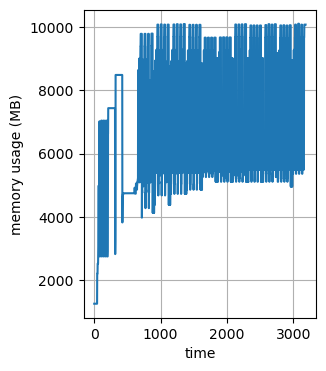

GPU MONITORING COMPLETE.


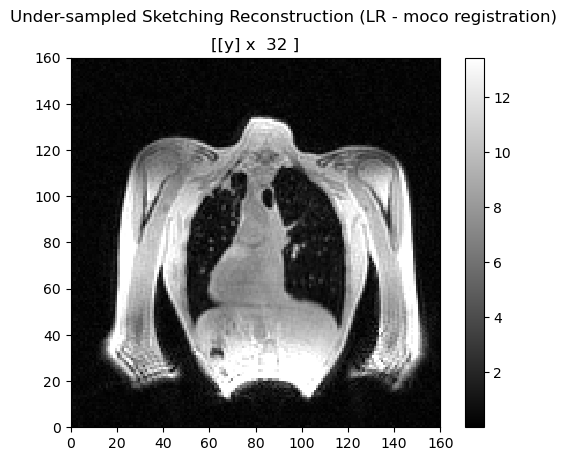

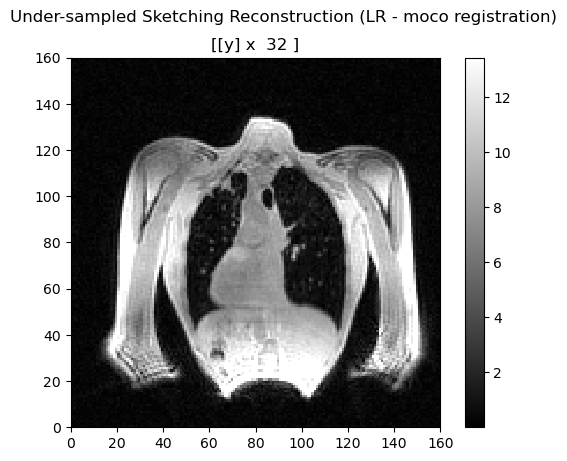

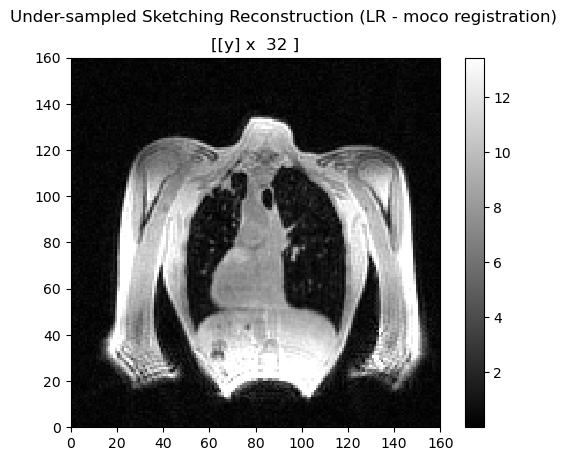

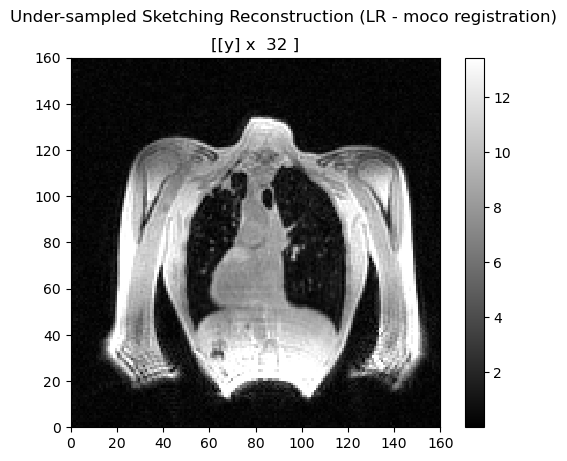

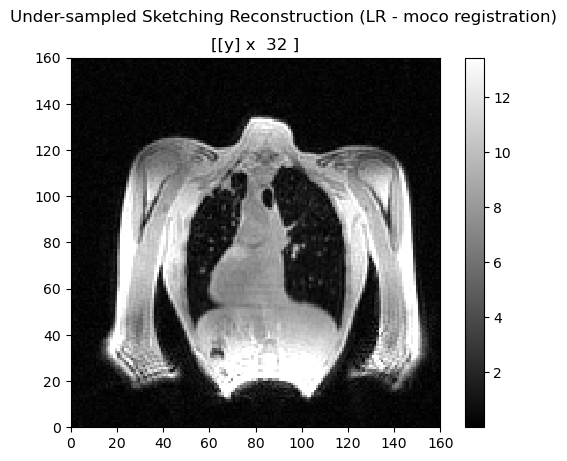

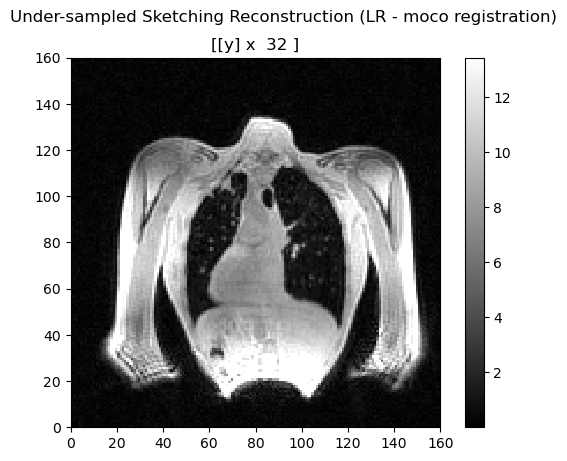

Sketched reconstruction with 3 coils:


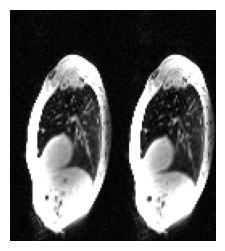

In [ ]:
if mocolor:
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    import sketching_app
    importlib.reload(sketching_app)
    import prox_ltr
    importlib.reload(prox_ltr)
    import registration_oflow3D
    importlib.reload(registration_oflow3D)
    import opticalflow3D
    importlib.reload(opticalflow3D)
    
    # Get memory usage statistics
    mempool = cp.get_default_memory_pool()
    pinned_mempool = cp.get_default_pinned_memory_pool()
    mempool.free_all_blocks()
    pinned_mempool.free_all_blocks()
    cp._default_memory_pool.free_all_blocks()
    cp.cuda.stream.get_current_stream().synchronize() 
    
    # Start monitoring
    print("MONITORING GPU USAGE...")
    tic, toc, memory_usage_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    tic()

    np.random.seed(1)
    img_sk_lr_moco_jacobian = mvc(scale*sk4d.SketchedMotionCompensatedLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=True,
                                    N_frames_per_block=nphase,
                                    # solver='GradientMethod', # Default
                                    solver='PrimalDualHybridGradient', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_lr_moco_jacobian, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_lr_moco_jacobian')
    
    sketched_memory_lor_moco = np.array(memory_usage_sketched)*1e-3
    toc()
    # Plot results
    plt.figure(figsize=(3,4))
    plt.plot(memory_usage_sketched)
    plt.xlabel('time')
    plt.ylabel('memory usage (MB)')
    plt.grid(True)
    plt.show()
    shutdown()
    print("GPU MONITORING COMPLETE.")

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_lr_moco_jacobian.ravel()), 95)
    for resp in range(nphase):
        pl.ImagePlot(img_sk_lr_moco_jacobian[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Sketching Reconstruction (LR - moco registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )
        
        
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_lr_moco_jacobian, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_mocolr.png', bbox_inches='tight', pad_inches=0)
    plt.show()
        

## Let's try a 4D Locally Low Rank recon (without registration)

If interested, we also implemented a locally low rank reconstruction. We did not use it in the paper. But it could be of some use if interested!

In [ ]:
if llor:
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)

    np.random.seed(1)
    img_sk_llr_no_moco = mvc(scale*sk4d.SketchedLocallyLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='GradientMethod', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())
    
    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_llr_no_moco, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_llr_no_moco')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_llr_no_moco.ravel()), 95)
    pl.ImagePlot(img_sk_llr_no_moco[0,...], 
                x=1, y=3,
                title="Under-sampled Sketching Reconstruction (LLR - no registration)", 
                colormap="gray", 
                vmax=vmax,
                )
    
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_llr_no_moco, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_llr_no_moco.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    
    img_llr_no_moco = mvc(scale*sk4d.SketchedLocallyLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nc,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='GradientMethod', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter + (max_outer_iter * (max_inner_iter-1)),
                                    max_outer_iter=0,
                                    max_inner_iter=0,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nc,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_llr_no_moco, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_llr_no_moco')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_llr_no_moco.ravel()), 95)
    pl.ImagePlot(img_llr_no_moco[0,...], 
                x=1, y=3,
                title="Under-sampled Reconstruction (LLR - no registration)", 
                colormap="gray", 
                vmax=vmax,
                )

Not regularizing the motion compensated images.
Using Gradient method to solve the reconstruction problem.
Double checking... self.solver = None
self.device = <CUDA Device 4>
Using a coil batch size of 3 in this reconstruction.
Using the same CSM for all respiratory phases.
Coil batch size of 3 coils supplied to Sense4D().
Coil batching with 3 coils out of 15 total coils.
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Using the same CSM for all respiratory phases.
Automated coil batch size = 3 set to nc = 3 inside Sense4D().
Not using Toeplitz PSF, moving coord and weights to device <CUDA Device 4> for f

# Let's plot some images


In [ ]:

# Define helper functions
def normalize(img, percentile=95):
    """Normalize the image to a given percentile."""
    img_n = img / np.percentile(img.ravel(), percentile)
    return img_n

def crop_2d(image, matrix_size):
    """Crop the center of a 2D image to a given size."""
    center = [dim // 2 for dim in image.shape]
    half_size = [msize // 2 for msize in matrix_size]
    slices = tuple(slice(c - h, c + h) for c, h in zip(center, half_size))
    return image[slices]

# Plot images
for resp in range(nphase):
    image = np.rot90(abs(img_sk_cg_sense[resp,...]), 2)
    tmp_slice = int(50*res_scale)  # Coronal slice (x, y)
    sag_slice = int(128*res_scale)   # Sagittal slice (y, z)
    voxel_crop = int(60*res_scale) 
    side_crop = -20

    # Extract slices for coronal and sagittal views
    coronal_view = normalize(image[voxel_crop:-voxel_crop, voxel_crop:-voxel_crop,tmp_slice])  # Coronal (x, y)
    sagittal_view = normalize(image[voxel_crop:-voxel_crop, sag_slice, :side_crop])  # Sagittal (y, z)

    # Concatenate views
    concatenated_view = np.concatenate((coronal_view, sagittal_view), axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(concatenated_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"CG-SENSE_concatenated_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(coronal_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"CG-SENSE_coronal_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Saved concatenated views to {output_path}")
    
    
    # Next image...
    image = np.rot90(abs(img_sk_tv[resp,...]), 2)

    # Extract slices for coronal and sagittal views
    coronal_view = normalize(image[voxel_crop:-voxel_crop, voxel_crop:-voxel_crop,tmp_slice])  # Coronal (x, y)
    sagittal_view = normalize(image[voxel_crop:-voxel_crop, sag_slice, :side_crop])  # Sagittal (y, z)

    # Concatenate views
    concatenated_view = np.concatenate((coronal_view, sagittal_view), axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(concatenated_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"TV_concatenated_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(coronal_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"TV_coronal_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Saved concatenated views to {output_path}")
    
    
    # Next image...
    image = np.rot90(abs(img_sk_lr_no_moco[resp,...]), 2)

    # Extract slices for coronal and sagittal views
    coronal_view = normalize(image[voxel_crop:-voxel_crop, voxel_crop:-voxel_crop,tmp_slice])  # Coronal (x, y)
    sagittal_view = normalize(image[voxel_crop:-voxel_crop, sag_slice, :side_crop])  # Sagittal (y, z)

    # Concatenate views
    concatenated_view = np.concatenate((coronal_view, sagittal_view), axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(concatenated_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"LOR_concatenated_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(coronal_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"LOR_coronal_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Saved concatenated views to {output_path}")
    
    
    # Next image...
    image = np.rot90(abs(img_sk_lr_moco_jacobian[resp,...]), 2)

    # Extract slices for coronal and sagittal views
    coronal_view = normalize(image[voxel_crop:-voxel_crop, voxel_crop:-voxel_crop,tmp_slice])  # Coronal (x, y)
    sagittal_view = normalize(image[voxel_crop:-voxel_crop, sag_slice, :side_crop])  # Sagittal (y, z)

    # Concatenate views
    concatenated_view = np.concatenate((coronal_view, sagittal_view), axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(concatenated_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"MOCOLOR_concatenated_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(coronal_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"MOCOLOR_coronal_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Saved concatenated views to {output_path}")